## 1. Import delle Librerie Necessarie

In [119]:
import pandas as pd
import numpy as np
import sys
sys.path.append('..')
from script.connessioni import get_mysql_connection

import matplotlib.pyplot as plt
import seaborn as sns
import os
import subprocess

# Configurazione pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_rows', 100)

# Scikit-learn
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Scipy
from scipy.stats import pearsonr

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("✓ Librerie caricate con successo")

✓ Librerie caricate con successo


## 2. Caricamento e Preparazione dei Dati

In [120]:
# Esecuzione script setup e pulizia dati
result_setup = subprocess.run([sys.executable, '../script/setup_raw_data.py'], 
                              capture_output=True, text=True)
print(result_setup.stdout)
if result_setup.stderr:
    print("STDERR:", result_setup.stderr)


Creazione tabella raw_data...
Tabella raw_data creata

Credenziali caricate!
Credenziali caricate da: c:\Users\Utente\OneDrive - ITS Tech Talent Factory\Project Work\Project-Work\script\..\local\analisi-ansia-dcecdb75c868.json

Connessione a Google Sheets...
Trovate 169 risposte
Numero colonne: 39

Inizio importazione dati in raw_data...

Salvate 10 righe...
Salvate 20 righe...
Salvate 30 righe...
Salvate 40 righe...
Salvate 50 righe...
Salvate 60 righe...
Salvate 70 righe...
Salvate 80 righe...
Salvate 90 righe...
Salvate 100 righe...
Salvate 110 righe...
Salvate 120 righe...
Salvate 130 righe...
Salvate 140 righe...
Salvate 150 righe...
Salvate 160 righe...

Importazione completata!
   - Righe inserite: 169
   - Righe saltate: 0

Fine

STDERR: c:\Users\Utente\OneDrive - ITS Tech Talent Factory\Project Work\Project-Work\venv\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.10) which Google will stop supporting in ne

In [121]:
# Esecuzione notebook pulizia con nbconvert
result_clean = subprocess.run([
    sys.executable, '-m', 'nbconvert', 
    '--to', 'notebook', 
    '--execute', 
    '--ExecutePreprocessor.timeout=600',
    '../notebook/pulizia.ipynb'
], capture_output=True, text=True, cwd='.')

print(result_clean.stdout)
if result_clean.stderr:
    print("STDERR:", result_clean.stderr)


STDERR: [NbConvertApp] Converting notebook ../notebook/pulizia.ipynb to notebook
c:\Users\Utente\OneDrive - ITS Tech Talent Factory\Project Work\Project-Work\venv\lib\site-packages\zmq\_future.py:718: RuntimeWarning: Proactor event loop does not implement add_reader family of methods required for zmq. Registering an additional selector thread for add_reader support via tornado. Use `asyncio.set_event_loop_policy(WindowsSelectorEventLoopPolicy())` to avoid this warning.
  self._get_loop()
[NbConvertApp] Writing 196867 bytes to ..\notebook\pulizia.nbconvert.ipynb



In [122]:
# Connessione al database e caricamento dati
conn = get_mysql_connection()
query = "SELECT * FROM clean_data"
df = pd.read_sql(query, conn)
conn.close()

print(f"Dataset caricato: {df.shape[0]} righe, {df.shape[1]} colonne")
print(f"\nTipo di dati:")
print(df.dtypes)
print(f"\nPrime righe:")
print(df.head())

Dataset caricato: 147 righe, 37 colonne

Tipo di dati:
id                   int64
email               object
contesto            object
età                  int64
genere              object
area_geo            object
anni_esperienza    float64
Item_1               int64
Item_2               int64
Item_3               int64
Item_4               int64
Item_5               int64
Item_6             float64
Item_7             float64
Item_8             float64
Item_9             float64
Item_10            float64
Item_11            float64
Item_12            float64
Item_13            float64
Item_14            float64
Item_15            float64
Item_16            float64
Item_17            float64
Item_18            float64
Item_19            float64
Item_20            float64
Item_21              int64
Item_22              int64
Item_23              int64
Item_24              int64
Item_25              int64
Item_26              int64
Item_27              int64
Item_28              int64


In [123]:
# Verifica informazioni dataset
print("\nInfo Dataset:")
df.info()
print(f"\nValori mancanti:\n{df.isnull().sum()}")


Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 37 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               147 non-null    int64  
 1   email            12 non-null     object 
 2   contesto         147 non-null    object 
 3   età              147 non-null    int64  
 4   genere           147 non-null    object 
 5   area_geo         147 non-null    object 
 6   anni_esperienza  147 non-null    float64
 7   Item_1           147 non-null    int64  
 8   Item_2           147 non-null    int64  
 9   Item_3           147 non-null    int64  
 10  Item_4           147 non-null    int64  
 11  Item_5           147 non-null    int64  
 12  Item_6           144 non-null    float64
 13  Item_7           144 non-null    float64
 14  Item_8           144 non-null    float64
 15  Item_9           145 non-null    float64
 16  Item_10          143 non-null    float64
 17  I

## 3. Calcolo degli Indici Psicologici

In [124]:
# Indici principali
df["ansia_prestazione"] = df[["Item_1", "Item_2", "Item_3", "Item_4", "Item_6", "Item_11", "Item_20", "Item_21"]].mean(axis=1)
df["ansia_accademica"] = df[["Item_7", "Item_8", "Item_9", "Item_10"]].mean(axis=1)
df["ansia_lavorativa"] = df[["Item_12", "Item_13", "Item_14", "Item_15"]].mean(axis=1)
df["perfezionismo"] = df[["Item_16", "Item_17", "Item_18", "Item_19"]].mean(axis=1)
df["impatto_ansia"] = df[["Item_5", "Item_22", "Item_27", "Item_28", "Item_29"]].mean(axis=1)
df["coping"] = df[["Item_23", "Item_24", "Item_25", "Item_26"]].mean(axis=1)

# Ansia totale
df['ansia'] = df[["ansia_prestazione", "ansia_accademica", "ansia_lavorativa"]].mean(axis=1)

# Indici derivati
df["vulnerabilita"] = (df["perfezionismo"] + df["ansia"]) / 2
df["resilienza"] = (df["coping"] - df["ansia"])
df["gap"] = (df["Item_8"] - df["coping"])
df["evitamento"] = df[["Item_10", "Item_15", "Item_27", "Item_28"]].mean(axis=1)
df["intensita_sintomatica"] = df[["Item_20", "Item_21", "Item_22"]].mean(axis=1)

# Elenco variabili disponibili
vars_to_analyze = [
    'ansia', 'coping', 'perfezionismo', 'vulnerabilita', 
    'resilienza', 'gap', 'evitamento', 'intensita_sintomatica',
    'impatto_ansia', 'ansia_prestazione', 'ansia_accademica', 
    'ansia_lavorativa'
]

vars_available = [v for v in vars_to_analyze if v in df.columns]
print(f"✓ Variabili psicologiche calcolate: {len(vars_available)}/{len(vars_to_analyze)}")
print(f"\nStatistiche descrittive:")
print(df[vars_available].describe())

✓ Variabili psicologiche calcolate: 12/12

Statistiche descrittive:
            ansia      coping  perfezionismo  vulnerabilita  resilienza  \
count  147.000000  147.000000      81.000000      81.000000  147.000000   
mean     2.920149    3.017007       3.111111       2.977697    0.096858   
std      0.866077    0.783859       1.011651       0.836640    1.425347   
min      1.214286    1.000000       1.000000       1.416667   -3.750000   
25%      2.261905    2.500000       2.250000       2.375000   -0.854167   
50%      2.910714    3.000000       3.250000       2.973214    0.291667   
75%      3.604167    3.625000       3.750000       3.544643    1.116071   
max      4.869048    4.750000       5.000000       4.803571    2.845238   

              gap  evitamento  intensita_sintomatica  impatto_ansia  \
count  144.000000  147.000000             147.000000     147.000000   
mean    -0.434028    2.425170               2.936508       3.194558   
std      1.587205    1.085296              

## 4. Analisi Esplorativa - Distribuzioni

In [125]:
# Funzione per salvare i grafici
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    """Salva figura nella cartella images"""
    if os.path.exists(f"../images/{fig_id}.{fig_extension}"):
        os.remove(f"../images/{fig_id}.{fig_extension}")
    path = os.path.join("../images", fig_id + "." + fig_extension)
    os.makedirs("../images", exist_ok=True)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)
    print(f"✓ Figura salvata: {fig_id}.{fig_extension}")

print("✓ Funzione save_fig definita")

✓ Funzione save_fig definita


✓ Figura salvata: 01_distribuzioni_indici.png


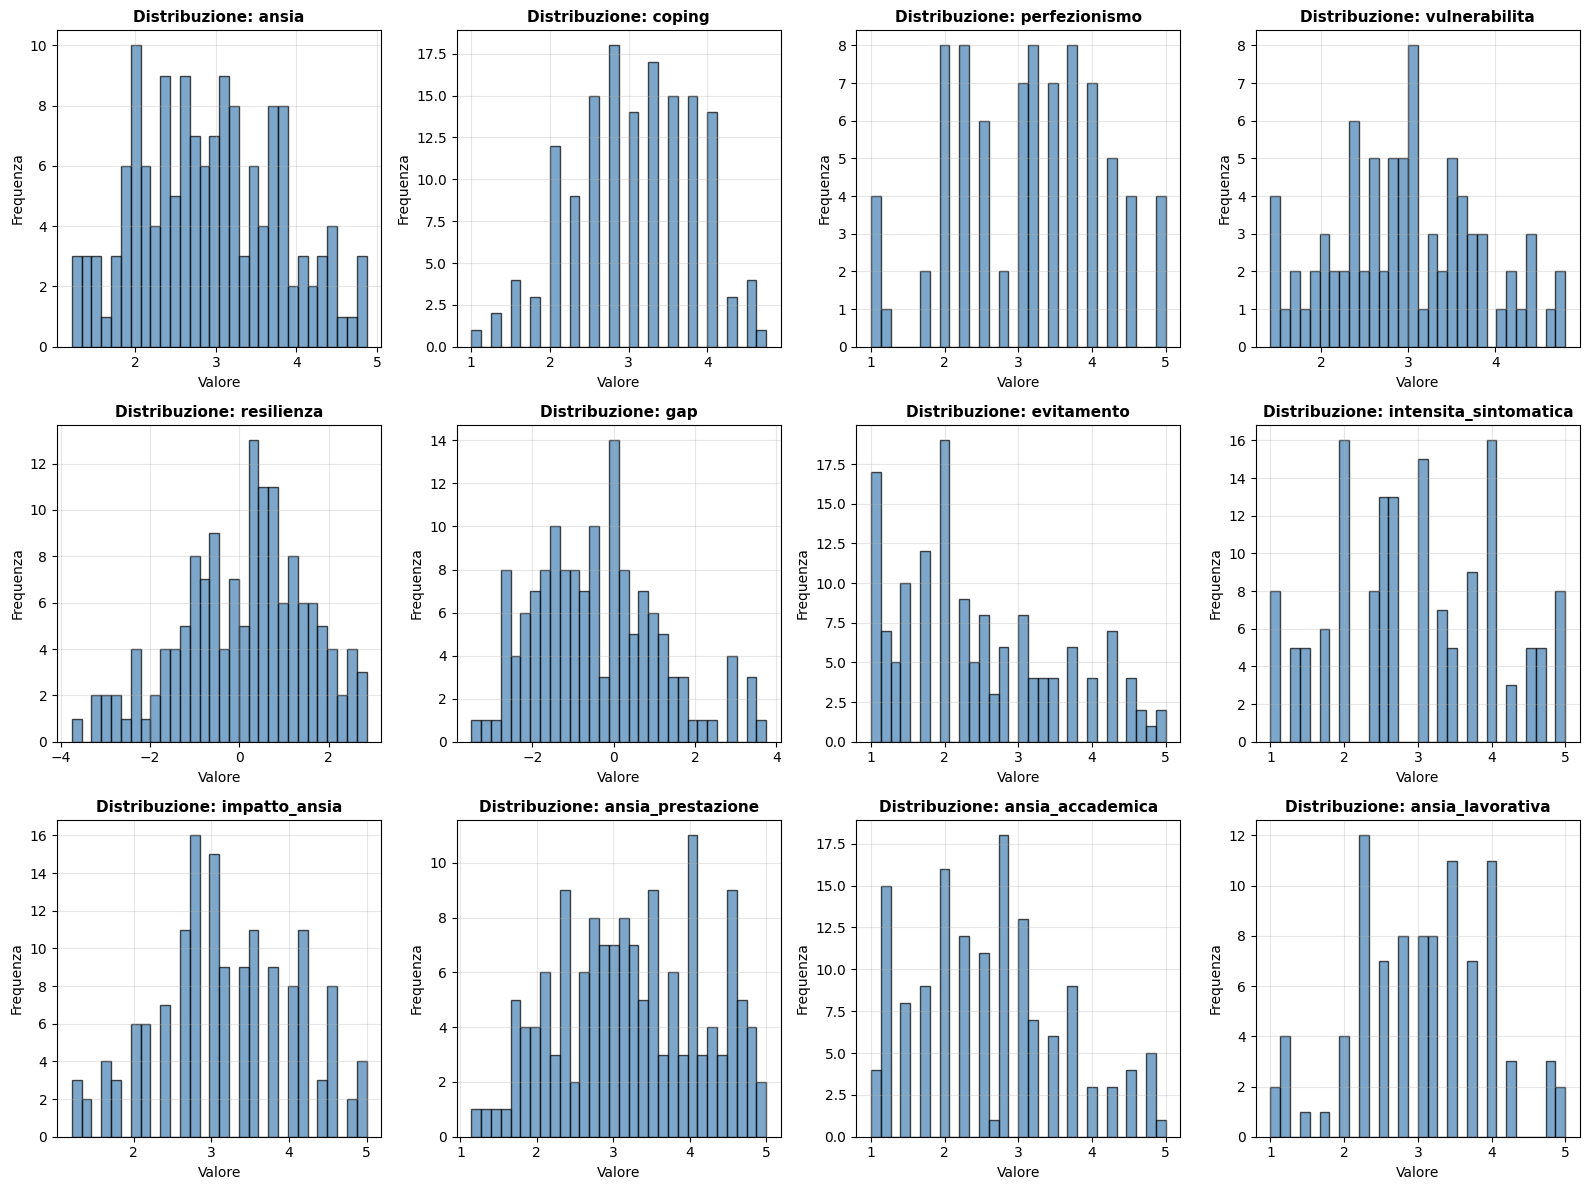

In [126]:
# Distribuzioni degli indici principali
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, var in enumerate(vars_available):
    axes[idx].hist(df[var].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribuzione: {var}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Valore')
    axes[idx].set_ylabel('Frequenza')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
save_fig("01_distribuzioni_indici")
plt.show()

✓ Figura salvata: 02_boxplot_indici.png


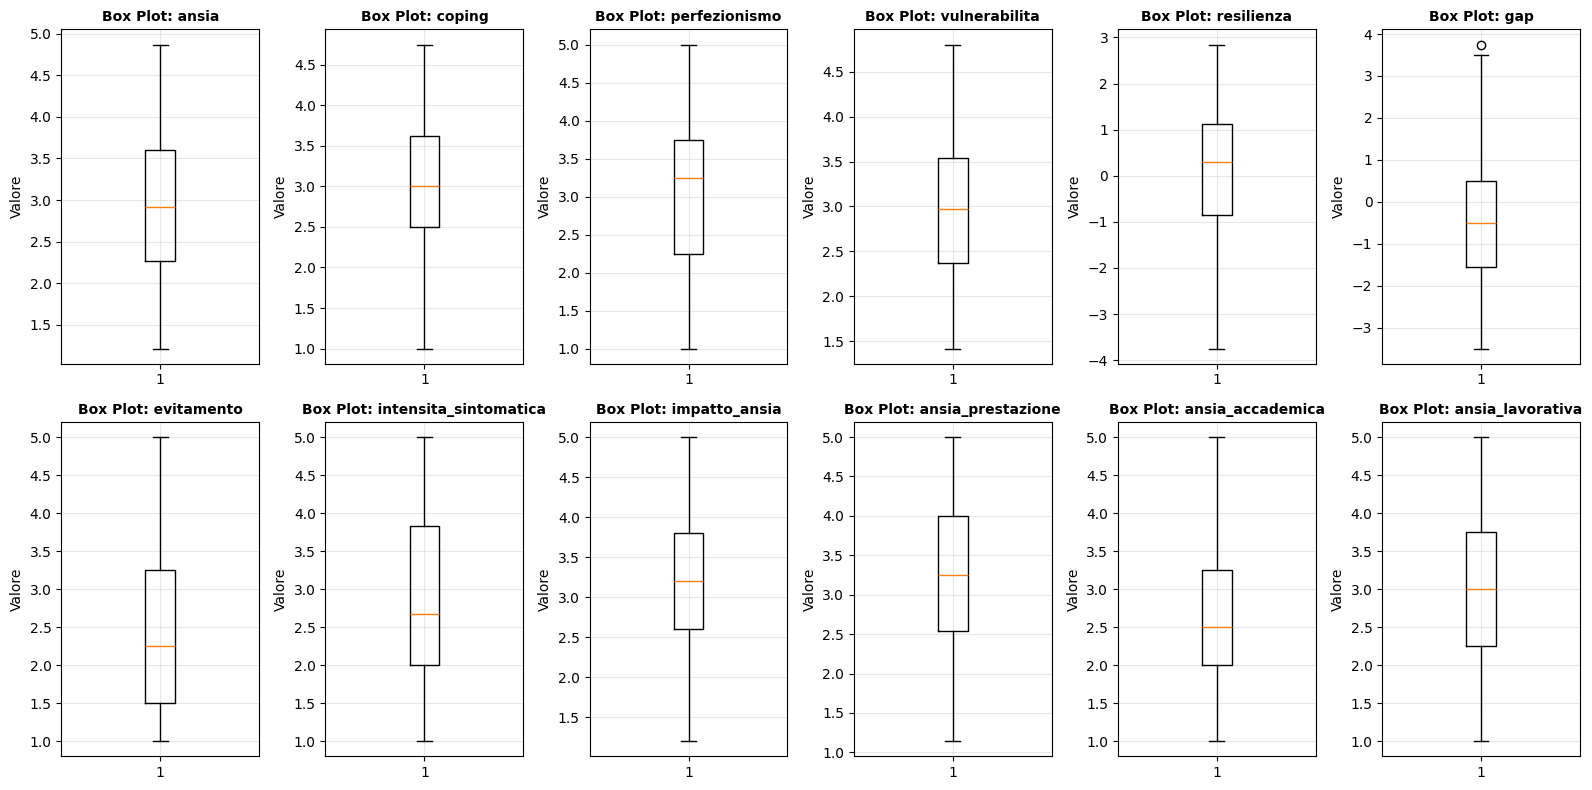

In [127]:
# Box plot per identificare outlier
fig, axes = plt.subplots(2, 6, figsize=(16, 8))
axes = axes.flatten()

for idx, var in enumerate(vars_available):
    axes[idx].boxplot(df[var].dropna(), vert=True)
    axes[idx].set_title(f'Box Plot: {var}', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Valore')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
save_fig("02_boxplot_indici")
plt.show()

## 5. Analisi delle Correlazioni

In [128]:
# Matrice di correlazione Pearson
corr_matrix = df[vars_available].corr(method='pearson')

print(f"✓ Matrice di correlazione {corr_matrix.shape} calcolata")
print(f"\nTop 5 correlazioni più forti:")
print(corr_matrix.round(3))

✓ Matrice di correlazione (12, 12) calcolata

Top 5 correlazioni più forti:
                       ansia  coping  perfezionismo  vulnerabilita  \
ansia                  1.000  -0.491          0.627          0.882   
coping                -0.491   1.000         -0.312         -0.434   
perfezionismo          0.627  -0.312          1.000          0.920   
vulnerabilita          0.882  -0.434          0.920          1.000   
resilienza            -0.878   0.848         -0.551         -0.772   
gap                    0.737  -0.671          0.459          0.666   
evitamento             0.792  -0.498          0.481          0.683   
intensita_sintomatica  0.805  -0.406          0.629          0.771   
impatto_ansia          0.805  -0.418          0.628          0.783   
ansia_prestazione      0.922  -0.484          0.663          0.861   
ansia_accademica       0.894  -0.464          0.498          0.763   
ansia_lavorativa       0.862  -0.318          0.350          0.655   

             

✓ Figura salvata: 03_matrice_correlazione.png


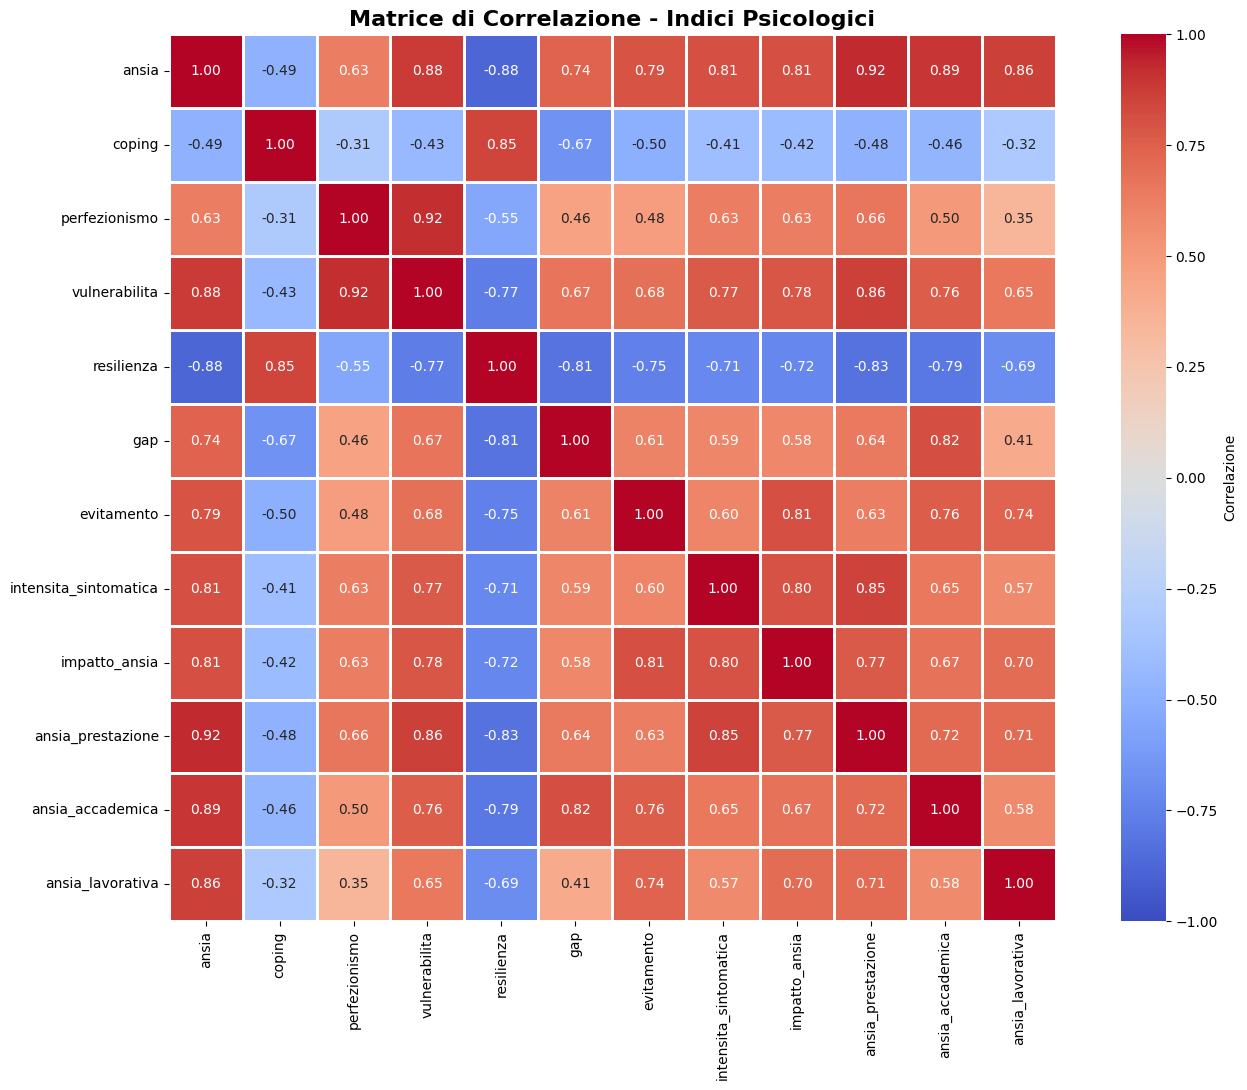

In [129]:
# Heatmap della matrice di correlazione
plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=1, cbar_kws={'label': 'Correlazione'},
            vmin=-1, vmax=1)
plt.title('Matrice di Correlazione - Indici Psicologici', fontsize=16, fontweight='bold')
plt.tight_layout()
save_fig("03_matrice_correlazione")
plt.show()

In [130]:
# Calcolo p-value e ranking delle correlazioni
df_clean = df[vars_available].dropna()
correlations_list = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        var1 = corr_matrix.columns[i]
        var2 = corr_matrix.columns[j]
        corr_value = corr_matrix.iloc[i, j]
        
        r, p_value = pearsonr(df_clean[var1], df_clean[var2])
        
        correlations_list.append({
            'Variabile 1': var1,
            'Variabile 2': var2,
            'Correlazione': corr_value,
            'Abs_Corr': abs(corr_value),
            'P-value': p_value,
            'Significativa (p<0.05)': 'Sì' if p_value < 0.05 else 'No'
        })

corr_df = pd.DataFrame(correlations_list)
corr_df_sorted = corr_df.sort_values('Abs_Corr', ascending=False)

print(f"\n✓ Analisi correlazioni completata ({len(corr_df)} coppie)")
print(f"\nTOP 15 CORRELAZIONI")
print(corr_df_sorted.head(15).to_string(index=False))


✓ Analisi correlazioni completata (66 coppie)

TOP 15 CORRELAZIONI
          Variabile 1           Variabile 2  Correlazione  Abs_Corr      P-value Significativa (p<0.05)
                ansia     ansia_prestazione      0.922039  0.922039 2.082988e-13                     Sì
        perfezionismo         vulnerabilita      0.920049  0.920049 2.414804e-13                     Sì
                ansia      ansia_accademica      0.893686  0.893686 4.033946e-13                     Sì
                ansia         vulnerabilita      0.882174  0.882174 2.639129e-11                     Sì
                ansia            resilienza     -0.877821  0.877821 2.853527e-12                     Sì
                ansia      ansia_lavorativa      0.862286  0.862286 5.966684e-10                     Sì
        vulnerabilita     ansia_prestazione      0.861436  0.861436 1.133883e-10                     Sì
intensita_sintomatica     ansia_prestazione      0.853828  0.853828 4.060124e-08                    

✓ Figura salvata: 04_scatter_correlazioni_top6.png


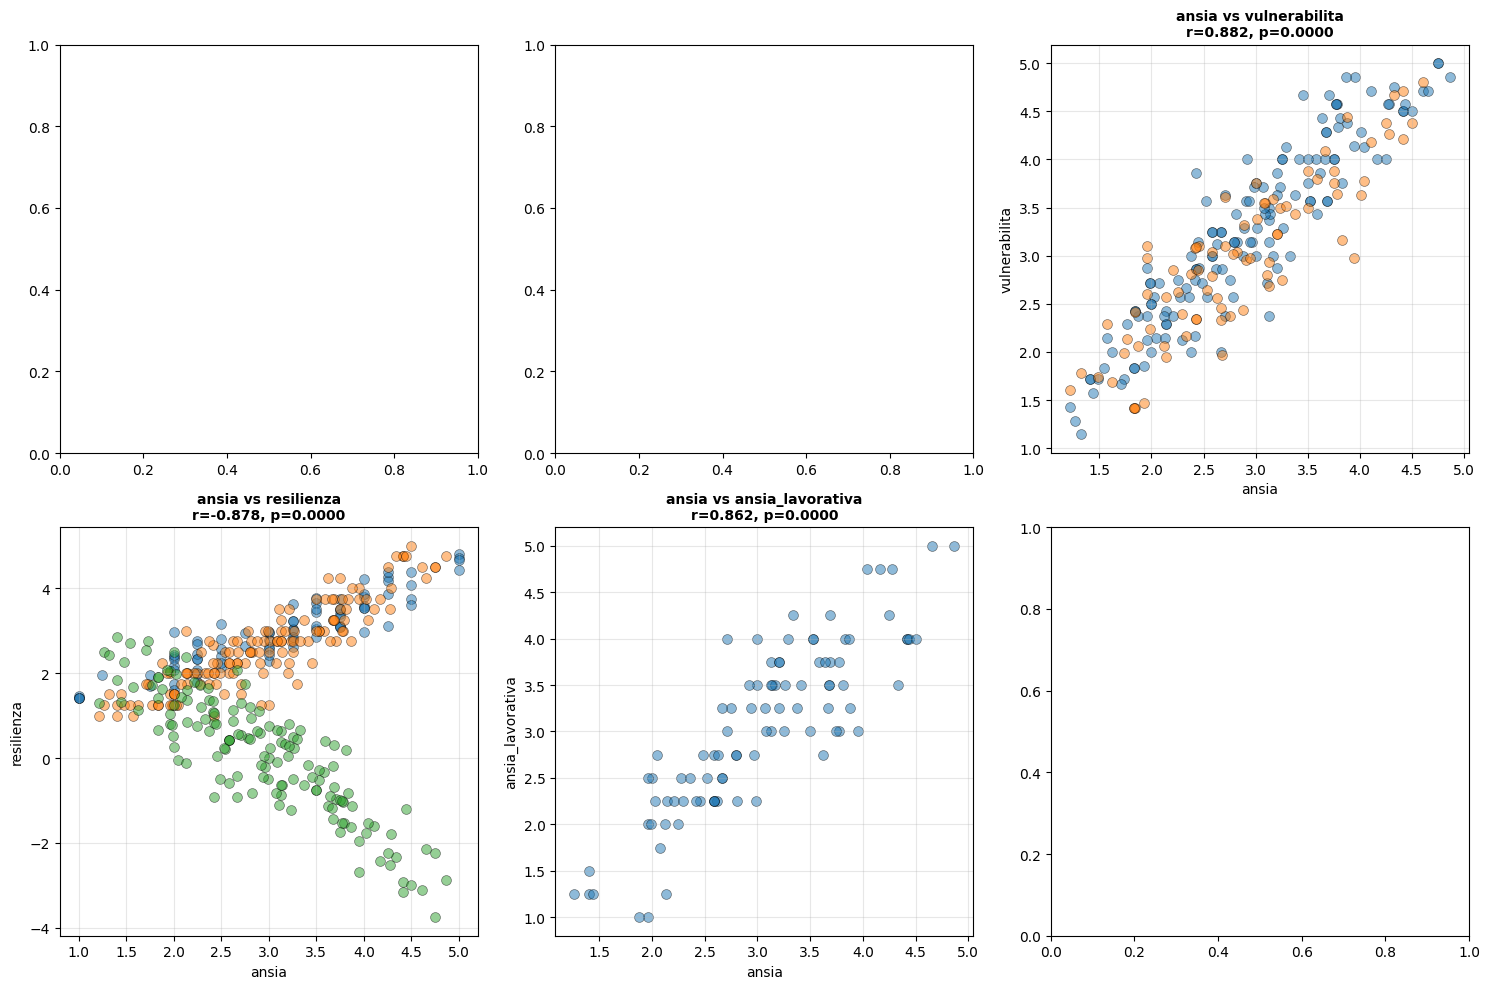

In [131]:
# Visualizzazione scatter plot delle correlazioni più significative
top_correlations = corr_df_sorted.head(6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, row in top_correlations.iterrows():
    ax = axes[idx % 6]
    var1, var2 = row['Variabile 1'], row['Variabile 2']
    corr_val = row['Correlazione']
    p_val = row['P-value']
    
    ax.scatter(df[var1], df[var2], alpha=0.5, s=50, edgecolors='black', linewidth=0.5)
    ax.set_xlabel(var1, fontsize=10)
    ax.set_ylabel(var2, fontsize=10)
    ax.set_title(f'{var1} vs {var2}\nr={corr_val:.3f}, p={p_val:.4f}', 
                fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
save_fig("04_scatter_correlazioni_top6")
plt.show()

## 6. Regressioni Lineari Semplici


REGRESSIONE 1: Resilienza → Evitamento
Train size: 117 | Test size: 30
R²: 0.6287 | RMSE: 0.5830 | MAE: 0.4834
Coefficiente: -0.5680 | Intercetta: 2.5074
✓ Figura salvata: 05_reg1_resilienza_evitamento.png


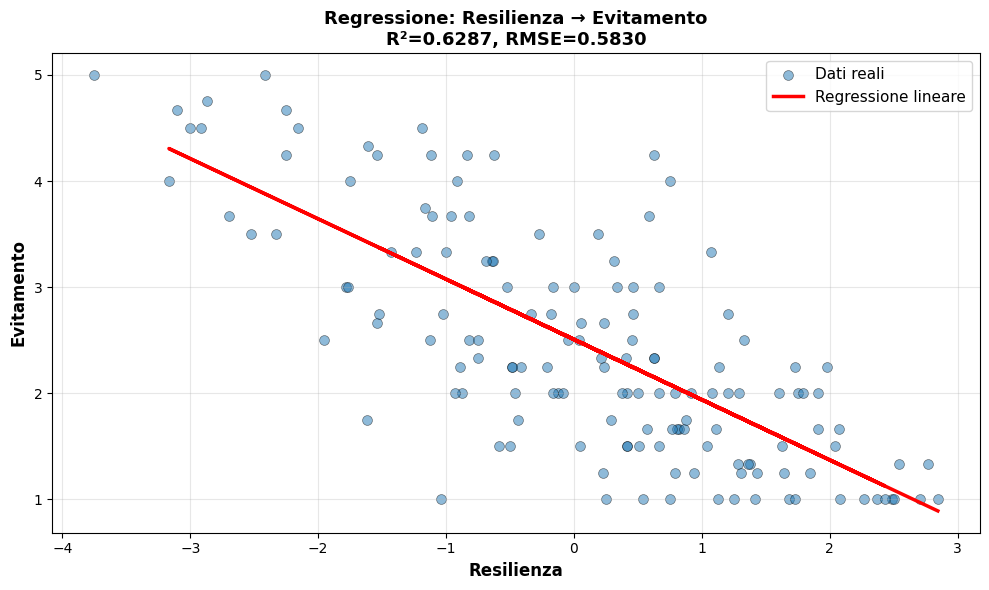

In [132]:
# Regressione 1: Resilienza vs Evitamento
print(f"\n{'='*70}")
print("REGRESSIONE 1: Resilienza → Evitamento")
print(f"{'='*70}")

X_1 = df[['resilienza']].values
y_1 = df['evitamento'].values

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.2, random_state=42)

lin_reg_1 = LinearRegression()
lin_reg_1.fit(X_train_1, y_train_1)
y_pred_1 = lin_reg_1.predict(X_test_1)

mse_1 = mean_squared_error(y_test_1, y_pred_1)
rmse_1 = np.sqrt(mse_1)
r2_1 = r2_score(y_test_1, y_pred_1)
mae_1 = mean_absolute_error(y_test_1, y_pred_1)

print(f"Train size: {len(X_train_1)} | Test size: {len(X_test_1)}")
print(f"R²: {r2_1:.4f} | RMSE: {rmse_1:.4f} | MAE: {mae_1:.4f}")
print(f"Coefficiente: {lin_reg_1.coef_[0]:.4f} | Intercetta: {lin_reg_1.intercept_:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(X_1, y_1, alpha=0.5, s=50, edgecolors='black', linewidth=0.5, label='Dati reali')
plt.plot(X_test_1, y_pred_1, 'r-', linewidth=2.5, label='Regressione lineare')
plt.xlabel("Resilienza", fontsize=12, fontweight='bold')
plt.ylabel("Evitamento", fontsize=12, fontweight='bold')
plt.title(f'Regressione: Resilienza → Evitamento\nR²={r2_1:.4f}, RMSE={rmse_1:.4f}', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
save_fig("05_reg1_resilienza_evitamento")
plt.show()


REGRESSIONE 2: Ansia → Evitamento
Train size: 117 | Test size: 30
R²: 0.6365 | RMSE: 0.5769 | MAE: 0.4507
Coefficiente: 0.9853 | Intercetta: -0.4474
✓ Figura salvata: 06_reg2_ansia_evitamento.png


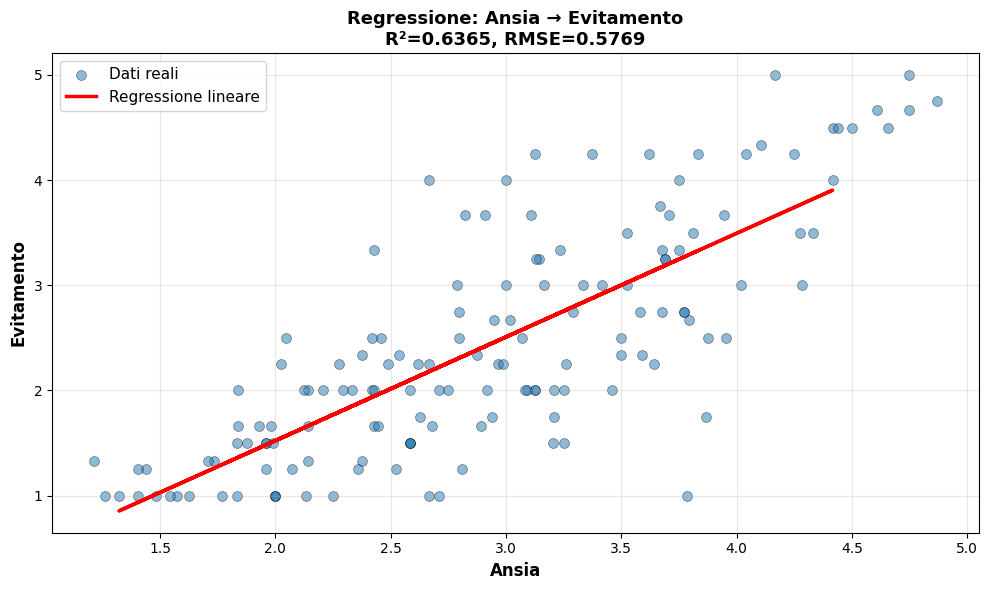

In [133]:
# Regressione 2: Ansia vs Evitamento
print(f"\n{'='*70}")
print("REGRESSIONE 2: Ansia → Evitamento")
print(f"{'='*70}")

X_2 = df[['ansia']].values
y_2 = df['evitamento'].values

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=42)

lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_train_2, y_train_2)
y_pred_2 = lin_reg_2.predict(X_test_2)

mse_2 = mean_squared_error(y_test_2, y_pred_2)
rmse_2 = np.sqrt(mse_2)
r2_2 = r2_score(y_test_2, y_pred_2)
mae_2 = mean_absolute_error(y_test_2, y_pred_2)

print(f"Train size: {len(X_train_2)} | Test size: {len(X_test_2)}")
print(f"R²: {r2_2:.4f} | RMSE: {rmse_2:.4f} | MAE: {mae_2:.4f}")
print(f"Coefficiente: {lin_reg_2.coef_[0]:.4f} | Intercetta: {lin_reg_2.intercept_:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(X_2, y_2, alpha=0.5, s=50, edgecolors='black', linewidth=0.5, label='Dati reali')
plt.plot(X_test_2, y_pred_2, 'r-', linewidth=2.5, label='Regressione lineare')
plt.xlabel("Ansia", fontsize=12, fontweight='bold')
plt.ylabel("Evitamento", fontsize=12, fontweight='bold')
plt.title(f'Regressione: Ansia → Evitamento\nR²={r2_2:.4f}, RMSE={rmse_2:.4f}', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
save_fig("06_reg2_ansia_evitamento")
plt.show()


REGRESSIONE 3: Ansia → Coping
Train size: 117 | Test size: 30
R²: 0.2269 | RMSE: 0.6733 | MAE: 0.5290
Coefficiente: -0.4405 | Intercetta: 4.3253
✓ Figura salvata: 07_reg3_ansia_coping_lineare.png


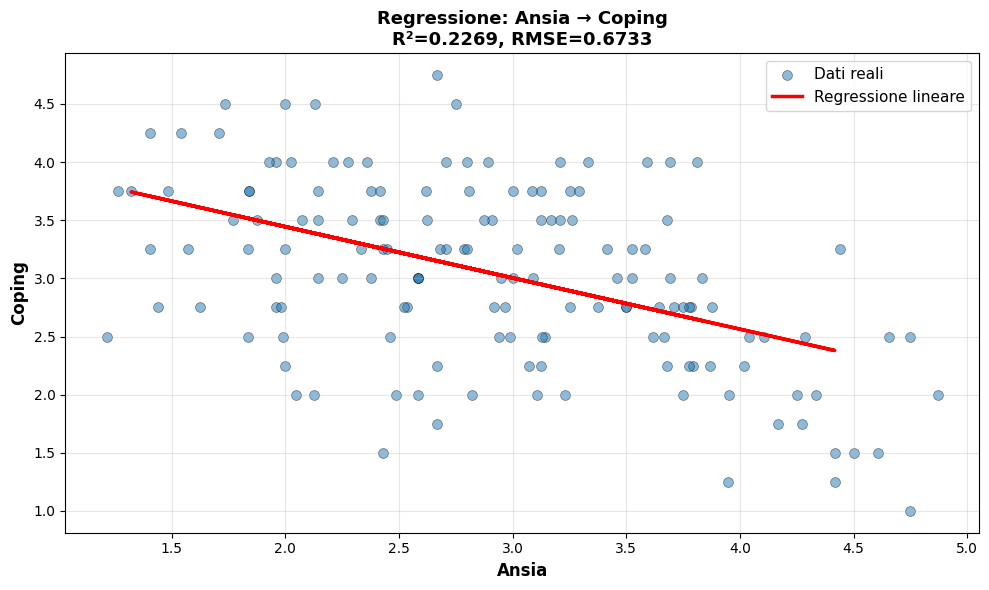

In [134]:
# Regressione 3: Ansia vs Coping
print(f"\n{'='*70}")
print("REGRESSIONE 3: Ansia → Coping")
print(f"{'='*70}")

X_3 = df[['ansia']].values
y_3 = df['coping'].values

X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_3, y_3, test_size=0.2, random_state=42)

lin_reg_3 = LinearRegression()
lin_reg_3.fit(X_train_3, y_train_3)
y_pred_3 = lin_reg_3.predict(X_test_3)

mse_3 = mean_squared_error(y_test_3, y_pred_3)
rmse_3 = np.sqrt(mse_3)
r2_3 = r2_score(y_test_3, y_pred_3)
mae_3 = mean_absolute_error(y_test_3, y_pred_3)

print(f"Train size: {len(X_train_3)} | Test size: {len(X_test_3)}")
print(f"R²: {r2_3:.4f} | RMSE: {rmse_3:.4f} | MAE: {mae_3:.4f}")
print(f"Coefficiente: {lin_reg_3.coef_[0]:.4f} | Intercetta: {lin_reg_3.intercept_:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(X_3, y_3, alpha=0.5, s=50, edgecolors='black', linewidth=0.5, label='Dati reali')
plt.plot(X_test_3, y_pred_3, 'r-', linewidth=2.5, label='Regressione lineare')
plt.xlabel("Ansia", fontsize=12, fontweight='bold')
plt.ylabel("Coping", fontsize=12, fontweight='bold')
plt.title(f'Regressione: Ansia → Coping\nR²={r2_3:.4f}, RMSE={rmse_3:.4f}', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
save_fig("07_reg3_ansia_coping_lineare")
plt.show()


REGRESSIONE 4: Ansia → Gap
Train size: 115 | Test size: 29
R²: 0.5358 | RMSE: 1.0340 | MAE: 0.8673
Coefficiente: 1.3875 | Intercetta: -4.5773
✓ Figura salvata: 08_reg4_ansia_gap_lineare.png


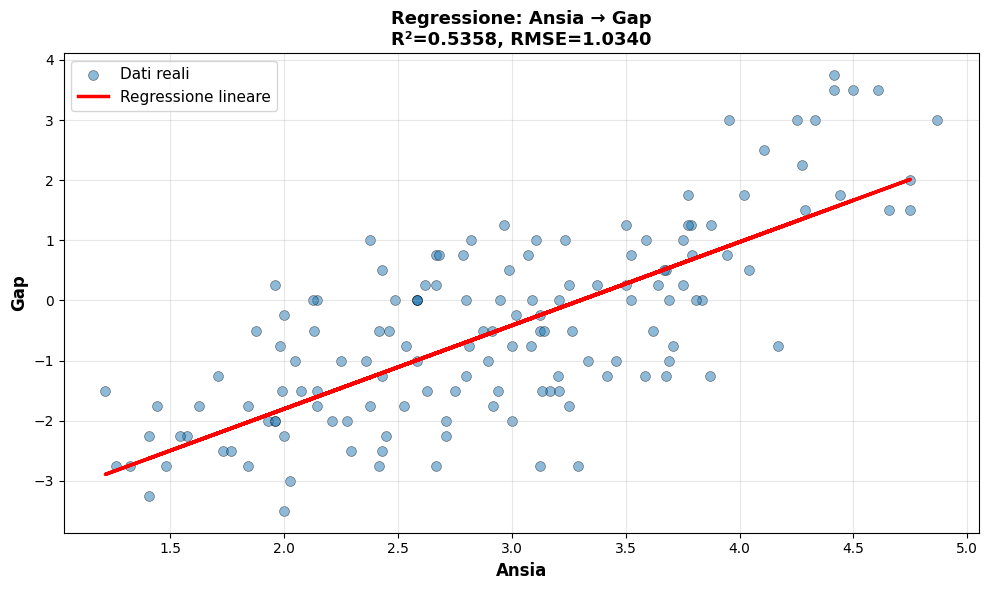

In [135]:
# Regressione 4: Ansia vs Gap
print(f"\n{'='*70}")
print("REGRESSIONE 4: Ansia → Gap")
print(f"{'='*70}")

df_reg4 = df.copy()
df_reg4 = df_reg4.dropna(subset=['ansia', 'gap'])

X_4 = df_reg4['ansia'].values.reshape(-1, 1)
y_4 = df_reg4['gap'].values.reshape(-1, 1)

X_train_4, X_test_4, y_train_4, y_test_4 = train_test_split(X_4, y_4, test_size=0.2, random_state=42)

lin_reg_4 = LinearRegression()
lin_reg_4.fit(X_train_4, y_train_4)
y_pred_4 = lin_reg_4.predict(X_test_4)

mse_4 = mean_squared_error(y_test_4, y_pred_4)
rmse_4 = np.sqrt(mse_4)
r2_4 = r2_score(y_test_4, y_pred_4)
mae_4 = mean_absolute_error(y_test_4, y_pred_4)

print(f"Train size: {len(X_train_4)} | Test size: {len(X_test_4)}")
print(f"R²: {r2_4:.4f} | RMSE: {rmse_4:.4f} | MAE: {mae_4:.4f}")
print(f"Coefficiente: {lin_reg_4.coef_[0][0]:.4f} | Intercetta: {lin_reg_4.intercept_[0]:.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(X_4, y_4, alpha=0.5, s=50, edgecolors='black', linewidth=0.5, label='Dati reali')
plt.plot(X_test_4, y_pred_4, 'r-', linewidth=2.5, label='Regressione lineare')
plt.xlabel("Ansia", fontsize=12, fontweight='bold')
plt.ylabel("Gap", fontsize=12, fontweight='bold')
plt.title(f'Regressione: Ansia → Gap\nR²={r2_4:.4f}, RMSE={rmse_4:.4f}', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
save_fig("08_reg4_ansia_gap_lineare")
plt.show()

In [136]:
# Riepilogo regressioni semplici
print(f"\n{'='*70}")
print("RIEPILOGO REGRESSIONI LINEARI SEMPLICI")
print(f"{'='*70}")

results_simple = pd.DataFrame({
    'Coppia': ['Resilienza → Evitamento', 'Ansia → Evitamento', 'Ansia → Coping', 'Ansia → Gap'],
    'R²': [r2_1, r2_2, r2_3, r2_4],
    'RMSE': [rmse_1, rmse_2, rmse_3, rmse_4],
    'MAE': [mae_1, mae_2, mae_3, mae_4]
})

print(results_simple.to_string(index=False))


RIEPILOGO REGRESSIONI LINEARI SEMPLICI
                 Coppia       R²     RMSE      MAE
Resilienza → Evitamento 0.628747 0.583031 0.483359
     Ansia → Evitamento 0.636512 0.576902 0.450710
         Ansia → Coping 0.226893 0.673306 0.529014
            Ansia → Gap 0.535799 1.033999 0.867263


## 7. Analisi di Regressione Polinomiale


REGRESSIONE POLINOMIALE: Ansia → Coping (grado 2)
R²: 0.2794 | RMSE: 0.6631
✓ Figura salvata: 09_reg3_ansia_coping_poly2.png


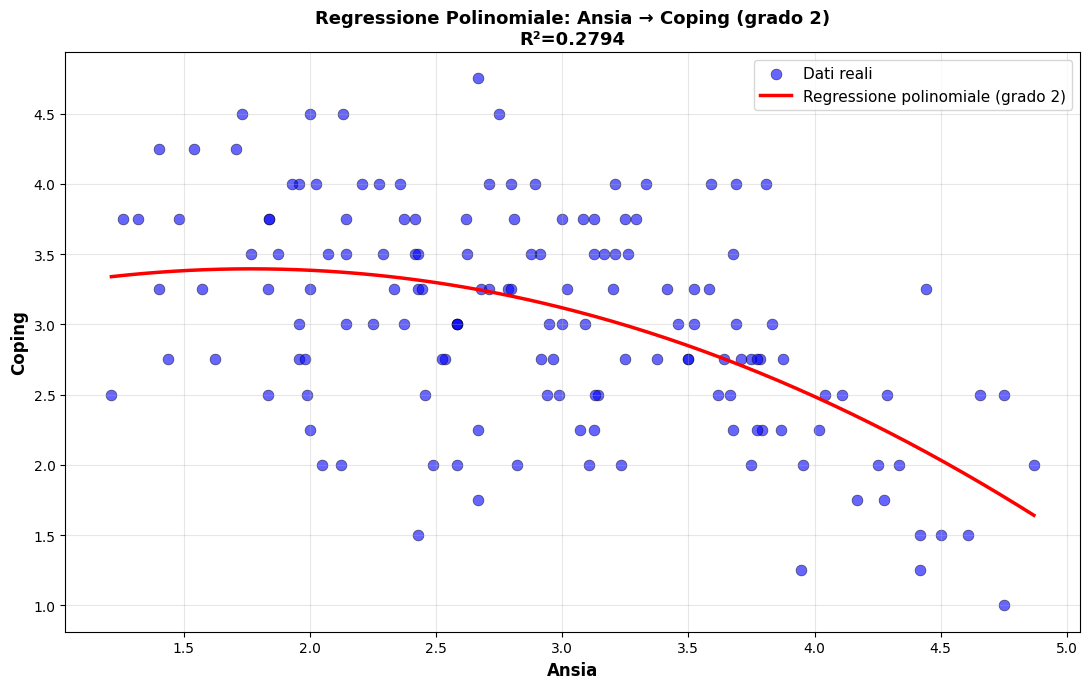

In [137]:
# Regressione Polinomiale 3: Ansia vs Coping (grado 2)
print(f"\n{'='*70}")
print("REGRESSIONE POLINOMIALE: Ansia → Coping (grado 2)")
print(f"{'='*70}")

poly_features_2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly_3_2 = poly_features_2.fit_transform(X_3)

lin_reg_poly_3_2 = LinearRegression()
lin_reg_poly_3_2.fit(X_poly_3_2, y_3)
y_pred_poly_3_2 = lin_reg_poly_3_2.predict(X_poly_3_2)

mse_poly_3_2 = mean_squared_error(y_3, y_pred_poly_3_2)
rmse_poly_3_2 = np.sqrt(mse_poly_3_2)
r2_poly_3_2 = r2_score(y_3, y_pred_poly_3_2)

print(f"R²: {r2_poly_3_2:.4f} | RMSE: {rmse_poly_3_2:.4f}")

X_smooth = np.linspace(X_3.min(), X_3.max(), 300).reshape(-1, 1)
X_smooth_poly = poly_features_2.transform(X_smooth)
y_smooth = lin_reg_poly_3_2.predict(X_smooth_poly)

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(X_3, y_3, alpha=0.6, s=60, color='blue', label='Dati reali', edgecolors='black', linewidth=0.5)
ax.plot(X_smooth, y_smooth, 'r-', linewidth=2.5, label='Regressione polinomiale (grado 2)')
ax.set_xlabel("Ansia", fontsize=12, fontweight='bold')
ax.set_ylabel("Coping", fontsize=12, fontweight='bold')
ax.set_title(f'Regressione Polinomiale: Ansia → Coping (grado 2)\nR²={r2_poly_3_2:.4f}', 
            fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("09_reg3_ansia_coping_poly2")
plt.show()


REGRESSIONE POLINOMIALE: Ansia → Coping (grado 3)
R²: 0.2831 | RMSE: 0.6614
✓ Figura salvata: 10_reg3_ansia_coping_poly3.png


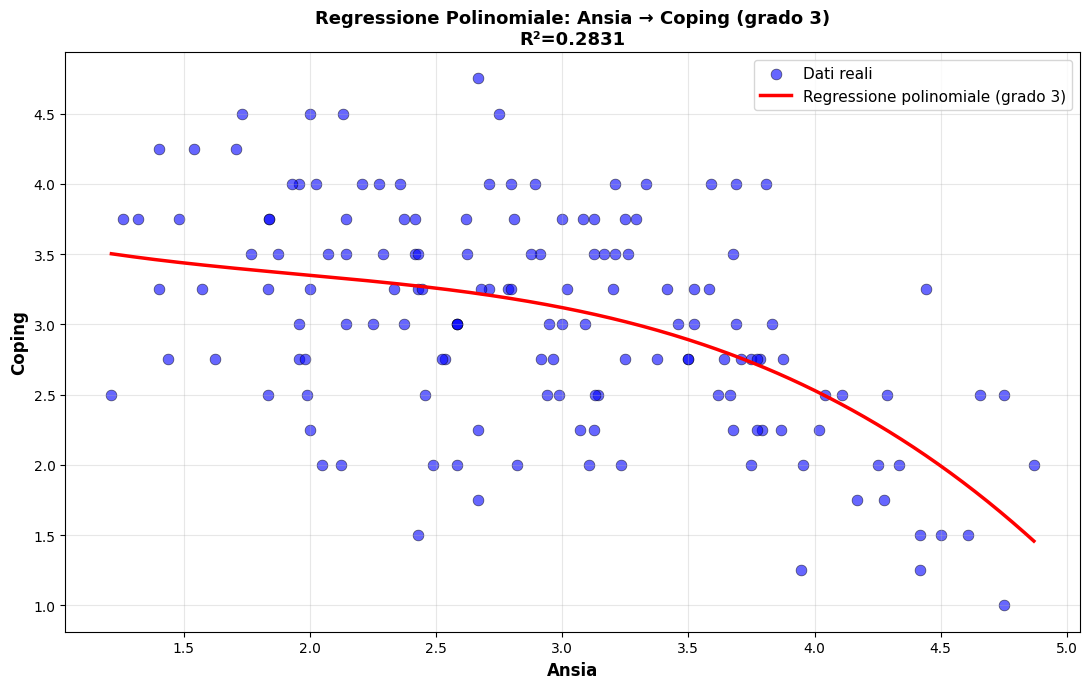

In [138]:
# Regressione Polinomiale 3: Ansia vs Coping (grado 3)
print(f"\n{'='*70}")
print("REGRESSIONE POLINOMIALE: Ansia → Coping (grado 3)")
print(f"{'='*70}")

poly_features_3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly_3_3 = poly_features_3.fit_transform(X_3)

lin_reg_poly_3_3 = LinearRegression()
lin_reg_poly_3_3.fit(X_poly_3_3, y_3)
y_pred_poly_3_3 = lin_reg_poly_3_3.predict(X_poly_3_3)

mse_poly_3_3 = mean_squared_error(y_3, y_pred_poly_3_3)
rmse_poly_3_3 = np.sqrt(mse_poly_3_3)
r2_poly_3_3 = r2_score(y_3, y_pred_poly_3_3)

print(f"R²: {r2_poly_3_3:.4f} | RMSE: {rmse_poly_3_3:.4f}")

X_smooth_poly_3 = poly_features_3.transform(X_smooth)
y_smooth_poly_3 = lin_reg_poly_3_3.predict(X_smooth_poly_3)

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(X_3, y_3, alpha=0.6, s=60, color='blue', label='Dati reali', edgecolors='black', linewidth=0.5)
ax.plot(X_smooth, y_smooth_poly_3, 'r-', linewidth=2.5, label='Regressione polinomiale (grado 3)')
ax.set_xlabel("Ansia", fontsize=12, fontweight='bold')
ax.set_ylabel("Coping", fontsize=12, fontweight='bold')
ax.set_title(f'Regressione Polinomiale: Ansia → Coping (grado 3)\nR²={r2_poly_3_3:.4f}', 
            fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("10_reg3_ansia_coping_poly3")
plt.show()

✓ Figura salvata: 11_reg3_confronto_modelli.png


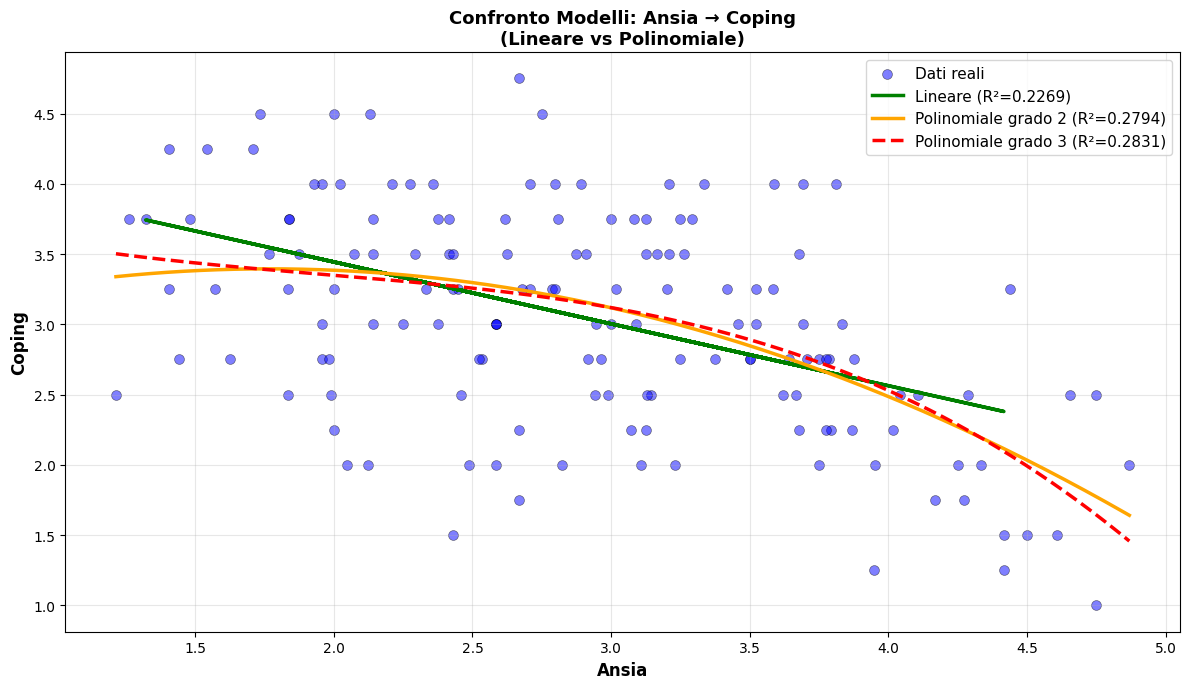

In [139]:
# Confronto Lineare vs Polinomiale grado 2 e 3 per Ansia vs Coping
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(X_3, y_3, alpha=0.5, s=50, color='blue', label='Dati reali', edgecolors='black', linewidth=0.5)
ax.plot(X_test_3, y_pred_3, 'g-', linewidth=2.5, label=f'Lineare (R²={r2_3:.4f})')
ax.plot(X_smooth, y_smooth, 'orange', linewidth=2.5, label=f'Polinomiale grado 2 (R²={r2_poly_3_2:.4f})')
ax.plot(X_smooth, y_smooth_poly_3, 'r--', linewidth=2.5, label=f'Polinomiale grado 3 (R²={r2_poly_3_3:.4f})')

ax.set_xlabel("Ansia", fontsize=12, fontweight='bold')
ax.set_ylabel("Coping", fontsize=12, fontweight='bold')
ax.set_title('Confronto Modelli: Ansia → Coping\n(Lineare vs Polinomiale)', 
            fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("11_reg3_confronto_modelli")
plt.show()


REGRESSIONE POLINOMIALE: Ansia → Gap (grado 2)
R²: 0.5657 | RMSE: 1.0424
✓ Figura salvata: 12_reg4_ansia_gap_poly2.png


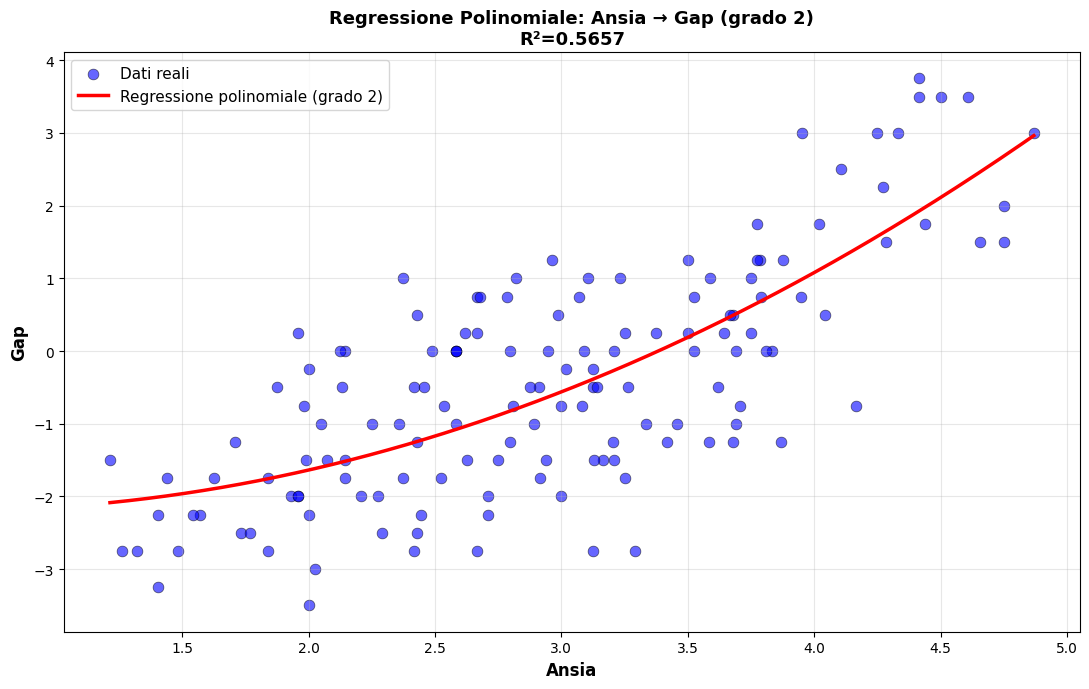

In [140]:
# Regressione Polinomiale 4: Ansia vs Gap (grado 2)
print(f"\n{'='*70}")
print("REGRESSIONE POLINOMIALE: Ansia → Gap (grado 2)")
print(f"{'='*70}")

poly_features_4_2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly_4_2 = poly_features_4_2.fit_transform(X_4)

lin_reg_poly_4_2 = LinearRegression()
lin_reg_poly_4_2.fit(X_poly_4_2, y_4)
y_pred_poly_4_2 = lin_reg_poly_4_2.predict(X_poly_4_2)

mse_poly_4_2 = mean_squared_error(y_4, y_pred_poly_4_2)
rmse_poly_4_2 = np.sqrt(mse_poly_4_2)
r2_poly_4_2 = r2_score(y_4, y_pred_poly_4_2)

print(f"R²: {r2_poly_4_2:.4f} | RMSE: {rmse_poly_4_2:.4f}")

X_smooth_4 = np.linspace(X_4.min(), X_4.max(), 300).reshape(-1, 1)
X_smooth_poly_4_2 = poly_features_4_2.transform(X_smooth_4)
y_smooth_4_2 = lin_reg_poly_4_2.predict(X_smooth_poly_4_2)

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(X_4, y_4, alpha=0.6, s=60, color='blue', label='Dati reali', edgecolors='black', linewidth=0.5)
ax.plot(X_smooth_4, y_smooth_4_2, 'r-', linewidth=2.5, label='Regressione polinomiale (grado 2)')
ax.set_xlabel("Ansia", fontsize=12, fontweight='bold')
ax.set_ylabel("Gap", fontsize=12, fontweight='bold')
ax.set_title(f'Regressione Polinomiale: Ansia → Gap (grado 2)\nR²={r2_poly_4_2:.4f}', 
            fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("12_reg4_ansia_gap_poly2")
plt.show()


REGRESSIONE POLINOMIALE: Ansia → Gap (grado 3)
R²: 0.5755 | RMSE: 1.0305
✓ Figura salvata: 13_reg4_ansia_gap_poly3.png


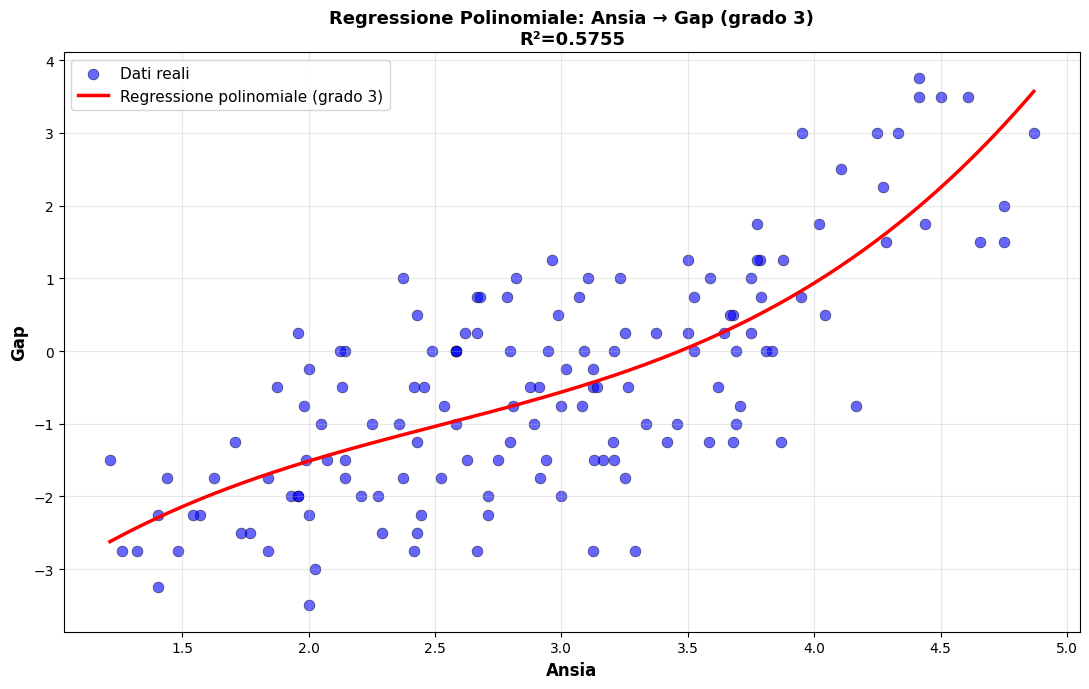

In [141]:
# Regressione Polinomiale 4: Ansia vs Gap (grado 3)
print(f"\n{'='*70}")
print("REGRESSIONE POLINOMIALE: Ansia → Gap (grado 3)")
print(f"{'='*70}")

poly_features_4_3 = PolynomialFeatures(degree=3, include_bias=False)
X_poly_4_3 = poly_features_4_3.fit_transform(X_4)

lin_reg_poly_4_3 = LinearRegression()
lin_reg_poly_4_3.fit(X_poly_4_3, y_4)
y_pred_poly_4_3 = lin_reg_poly_4_3.predict(X_poly_4_3)

mse_poly_4_3 = mean_squared_error(y_4, y_pred_poly_4_3)
rmse_poly_4_3 = np.sqrt(mse_poly_4_3)
r2_poly_4_3 = r2_score(y_4, y_pred_poly_4_3)

print(f"R²: {r2_poly_4_3:.4f} | RMSE: {rmse_poly_4_3:.4f}")

X_smooth_poly_4_3 = poly_features_4_3.transform(X_smooth_4)
y_smooth_4_3 = lin_reg_poly_4_3.predict(X_smooth_poly_4_3)

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(X_4, y_4, alpha=0.6, s=60, color='blue', label='Dati reali', edgecolors='black', linewidth=0.5)
ax.plot(X_smooth_4, y_smooth_4_3, 'r-', linewidth=2.5, label='Regressione polinomiale (grado 3)')
ax.set_xlabel("Ansia", fontsize=12, fontweight='bold')
ax.set_ylabel("Gap", fontsize=12, fontweight='bold')
ax.set_title(f'Regressione Polinomiale: Ansia → Gap (grado 3)\nR²={r2_poly_4_3:.4f}', 
            fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("13_reg4_ansia_gap_poly3")
plt.show()

✓ Figura salvata: 14_reg4_confronto_modelli.png


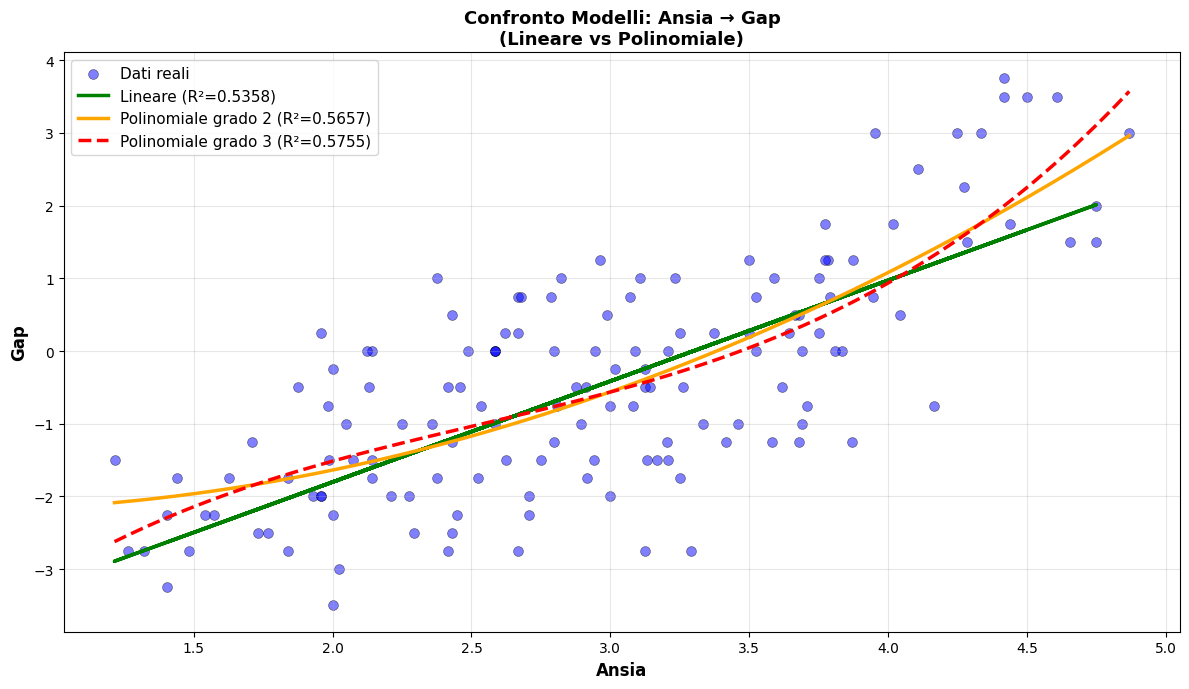

In [142]:
# Confronto Lineare vs Polinomiale per Ansia vs Gap
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(X_4, y_4, alpha=0.5, s=50, color='blue', label='Dati reali', edgecolors='black', linewidth=0.5)
ax.plot(X_test_4, y_pred_4, 'g-', linewidth=2.5, label=f'Lineare (R²={r2_4:.4f})')
ax.plot(X_smooth_4, y_smooth_4_2, 'orange', linewidth=2.5, label=f'Polinomiale grado 2 (R²={r2_poly_4_2:.4f})')
ax.plot(X_smooth_4, y_smooth_4_3, 'r--', linewidth=2.5, label=f'Polinomiale grado 3 (R²={r2_poly_4_3:.4f})')

ax.set_xlabel("Ansia", fontsize=12, fontweight='bold')
ax.set_ylabel("Gap", fontsize=12, fontweight='bold')
ax.set_title('Confronto Modelli: Ansia → Gap\n(Lineare vs Polinomiale)', 
            fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("14_reg4_confronto_modelli")
plt.show()

In [143]:
# Riepilogo Regressioni Polinomiali
print(f"\n{'='*90}")
print("RIEPILOGO REGRESSIONI POLINOMIALI")
print(f"{'='*90}")

poly_results = pd.DataFrame({
    'Coppia': ['Ansia → Coping', 'Ansia → Coping', 'Ansia → Coping', 
               'Ansia → Gap', 'Ansia → Gap', 'Ansia → Gap'],
    'Modello': ['Lineare', 'Polinomiale (grado 2)', 'Polinomiale (grado 3)',
                'Lineare', 'Polinomiale (grado 2)', 'Polinomiale (grado 3)'],
    'R²': [r2_3, r2_poly_3_2, r2_poly_3_3, r2_4, r2_poly_4_2, r2_poly_4_3],
    'RMSE': [rmse_3, rmse_poly_3_2, rmse_poly_3_3, rmse_4, rmse_poly_4_2, rmse_poly_4_3]
})

print(poly_results.to_string(index=False))


RIEPILOGO REGRESSIONI POLINOMIALI
        Coppia               Modello       R²     RMSE
Ansia → Coping               Lineare 0.226893 0.673306
Ansia → Coping Polinomiale (grado 2) 0.279446 0.663115
Ansia → Coping Polinomiale (grado 3) 0.283067 0.661447
   Ansia → Gap               Lineare 0.535799 1.033999
   Ansia → Gap Polinomiale (grado 2) 0.565660 1.042401
   Ansia → Gap Polinomiale (grado 3) 0.575547 1.030468


## 8. Confronto Modelli Avanzati - Linear, Ridge, Lasso

In [144]:
# Preparazione dati per modelli avanzati Ansia → Coping
print(f"\n{'='*70}")
print("CONFRONTO MODELLI AVANZATI: Ansia → Coping")
print(f"{'='*70}")

# Filtra variabili correttamente
features_full = [v for v in vars_available if v != 'coping']
df_clean_full = df[features_full + ['coping']].dropna()  # Ordine preciso

X = df_clean_full[features_full].values
y = df_clean_full['coping'].values
y = y.flatten()

# Normalizza
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\nDataset: {len(df_clean_full)} campioni")
print(f"Features: {len(features_full)} → {X_train.shape[1]}")
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# Verifica
assert len(features_full) == X_train.shape[1], "Mismatch features!"
print("✓ Dimensioni coerenti")


CONFRONTO MODELLI AVANZATI: Ansia → Coping

Dataset: 38 campioni
Features: 11 → 11
Train: 30 | Test: 8
✓ Dimensioni coerenti


In [145]:
# Test Ridge Regression con diversi alpha
print(f"\n{'='*70}")
print("RIDGE REGRESSION - Variazione Alpha")
print(f"{'='*70}")

alpha_values_ridge = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_results = []

for alpha in alpha_values_ridge:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    y_pred_train = ridge.predict(X_train)
    y_pred_test = ridge.predict(X_test)
    
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae_test = mean_absolute_error(y_test, y_pred_test)
    
    ridge_results.append({
        'Alpha': alpha,
        'R² Train': r2_train,
        'R² Test': r2_test,
        'RMSE Test': rmse_test,
        'MAE Test': mae_test
    })
    
    print(f"α={alpha:6.2f}: R² Train={r2_train:.4f} | R² Test={r2_test:.4f} | RMSE={rmse_test:.4f}")

ridge_df = pd.DataFrame(ridge_results)


RIDGE REGRESSION - Variazione Alpha
α=  0.01: R² Train=1.0000 | R² Test=1.0000 | RMSE=0.0053
α=  0.10: R² Train=0.9991 | R² Test=0.9981 | RMSE=0.0467
α=  1.00: R² Train=0.9763 | R² Test=0.9458 | RMSE=0.2519
α= 10.00: R² Train=0.8452 | R² Test=0.6324 | RMSE=0.6564
α=100.00: R² Train=0.6125 | R² Test=0.2564 | RMSE=0.9335


In [146]:
# Test Lasso Regression con diversi alpha
print(f"\n{'='*70}")
print("LASSO REGRESSION - Variazione Alpha")
print(f"{'='*70}")

alpha_values_lasso = [0.0001, 0.001, 0.01, 0.1, 1.0]
lasso_results = []

for alpha in alpha_values_lasso:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)
    y_pred_train = lasso.predict(X_train)
    y_pred_test = lasso.predict(X_test)
    
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae_test = mean_absolute_error(y_test, y_pred_test)
    n_features_selected = np.sum(lasso.coef_ != 0)
    
    lasso_results.append({
        'Alpha': alpha,
        'R² Train': r2_train,
        'R² Test': r2_test,
        'RMSE Test': rmse_test,
        'MAE Test': mae_test,
        'Features Selected': n_features_selected
    })
    
    print(f"α={alpha:.4f}: R² Train={r2_train:.4f} | R² Test={r2_test:.4f} | RMSE={rmse_test:.4f} | Feat. Sel.={n_features_selected}")

lasso_df = pd.DataFrame(lasso_results)


LASSO REGRESSION - Variazione Alpha
α=0.0001: R² Train=1.0000 | R² Test=1.0000 | RMSE=0.0012 | Feat. Sel.=5
α=0.0010: R² Train=0.9999 | R² Test=0.9999 | RMSE=0.0111 | Feat. Sel.=4
α=0.0100: R² Train=0.9950 | R² Test=0.9896 | RMSE=0.1102 | Feat. Sel.=4
α=0.1000: R² Train=0.8271 | R² Test=0.6248 | RMSE=0.6631 | Feat. Sel.=2
α=1.0000: R² Train=0.0000 | R² Test=-0.0768 | RMSE=1.1233 | Feat. Sel.=0


✓ Figura salvata: 15_ridge_vs_lasso.png


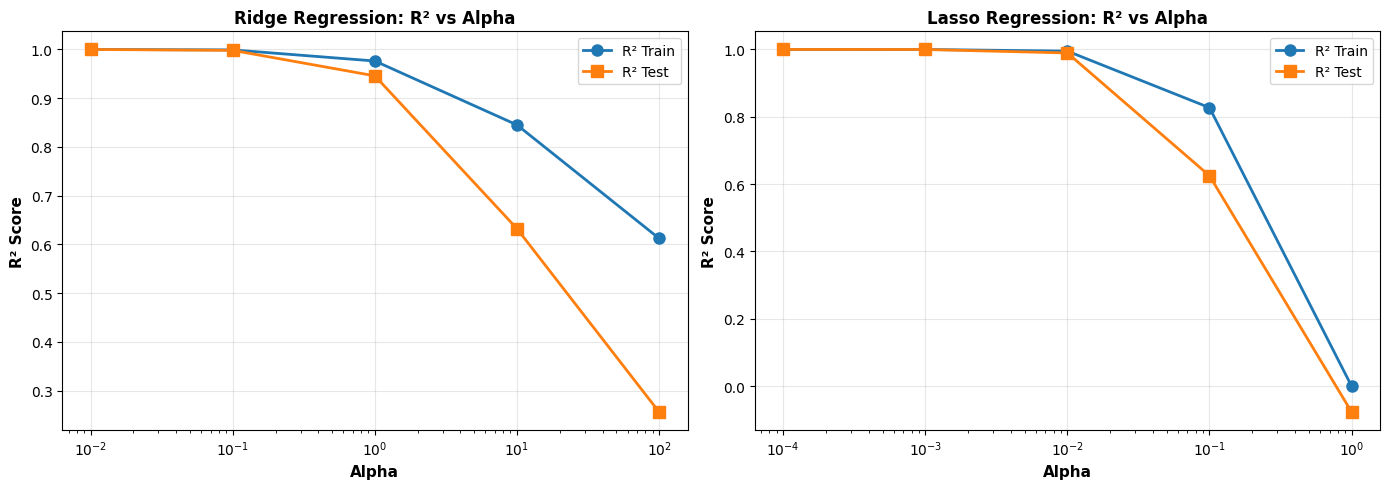

In [147]:
# Visualizzazione Ridge vs Lasso
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge
ax1 = axes[0]
ax1.plot(ridge_df['Alpha'], ridge_df['R² Train'], 'o-', label='R² Train', linewidth=2, markersize=8)
ax1.plot(ridge_df['Alpha'], ridge_df['R² Test'], 's-', label='R² Test', linewidth=2, markersize=8)
ax1.set_xscale('log')
ax1.set_xlabel('Alpha', fontsize=11, fontweight='bold')
ax1.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax1.set_title('Ridge Regression: R² vs Alpha', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Lasso
ax2 = axes[1]
ax2.plot(lasso_df['Alpha'], lasso_df['R² Train'], 'o-', label='R² Train', linewidth=2, markersize=8)
ax2.plot(lasso_df['Alpha'], lasso_df['R² Test'], 's-', label='R² Test', linewidth=2, markersize=8)
ax2.set_xscale('log')
ax2.set_xlabel('Alpha', fontsize=11, fontweight='bold')
ax2.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax2.set_title('Lasso Regression: R² vs Alpha', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
save_fig("15_ridge_vs_lasso")
plt.show()

In [148]:
# Modelli base per confronto
print(f"\n{'='*70}")
print("MODELLI BASE: Linear, Ridge (best), Lasso (best)")
print(f"{'='*70}")

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin_train = lin_reg.predict(X_train)
y_pred_lin_test = lin_reg.predict(X_test)

ridge_best = Ridge(alpha=1.0)
ridge_best.fit(X_train, y_train)
y_pred_ridge_train = ridge_best.predict(X_train)
y_pred_ridge_test = ridge_best.predict(X_test)

lasso_best = Lasso(alpha=0.001, max_iter=10000)
lasso_best.fit(X_train, y_train)
y_pred_lasso_train = lasso_best.predict(X_train)
y_pred_lasso_test = lasso_best.predict(X_test)

base_models_results = pd.DataFrame({
    'Modello': ['Linear', 'Ridge (α=1.0)', 'Lasso (α=0.001)'],
    'R² Train': [r2_score(y_train, y_pred_lin_train), 
                 r2_score(y_train, y_pred_ridge_train),
                 r2_score(y_train, y_pred_lasso_train)],
    'R² Test': [r2_score(y_test, y_pred_lin_test),
                r2_score(y_test, y_pred_ridge_test),
                r2_score(y_test, y_pred_lasso_test)],
    'RMSE Test': [np.sqrt(mean_squared_error(y_test, y_pred_lin_test)),
                  np.sqrt(mean_squared_error(y_test, y_pred_ridge_test)),
                  np.sqrt(mean_squared_error(y_test, y_pred_lasso_test))],
    'MAE Test': [mean_absolute_error(y_test, y_pred_lin_test),
                 mean_absolute_error(y_test, y_pred_ridge_test),
                 mean_absolute_error(y_test, y_pred_lasso_test)]
})

print(base_models_results.to_string(index=False))


MODELLI BASE: Linear, Ridge (best), Lasso (best)
        Modello  R² Train  R² Test    RMSE Test     MAE Test
         Linear  1.000000 1.000000 6.661338e-16 5.551115e-16
  Ridge (α=1.0)  0.976312 0.945847 2.519127e-01 2.193274e-01
Lasso (α=0.001)  0.999950 0.999894 1.114981e-02 9.050385e-03


## 9. Modelli Ensemble - Random Forest e Gradient Boosting

In [149]:
# Random Forest Regressor
print(f"\n{'='*70}")
print("RANDOM FOREST REGRESSOR")
print(f"{'='*70}")

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
rf.fit(X_train, y_train)
y_pred_rf_train = rf.predict(X_train)
y_pred_rf_test = rf.predict(X_test)

r2_rf_train = r2_score(y_train, y_pred_rf_train)
r2_rf_test = r2_score(y_test, y_pred_rf_test)
rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
mae_rf_test = mean_absolute_error(y_test, y_pred_rf_test)

print(f"R² Train: {r2_rf_train:.4f}")
print(f"R² Test: {r2_rf_test:.4f}")
print(f"RMSE Test: {rmse_rf_test:.4f}")
print(f"MAE Test: {mae_rf_test:.4f}")

# Feature importance
feature_importance_rf = pd.DataFrame({
    'Feature': features_full,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nTop 10 Feature Importance:")
print(feature_importance_rf.head(10).to_string(index=False))


RANDOM FOREST REGRESSOR
R² Train: 0.9649
R² Test: 0.5311
RMSE Test: 0.7412
MAE Test: 0.6384

Top 10 Feature Importance:
              Feature  Importance
           resilienza    0.478490
                  gap    0.216318
     ansia_accademica    0.104000
                ansia    0.036056
           evitamento    0.034100
    ansia_prestazione    0.033210
        perfezionismo    0.032081
        vulnerabilita    0.028944
intensita_sintomatica    0.017500
        impatto_ansia    0.011974


✓ Figura salvata: 16_rf_feature_importance.png


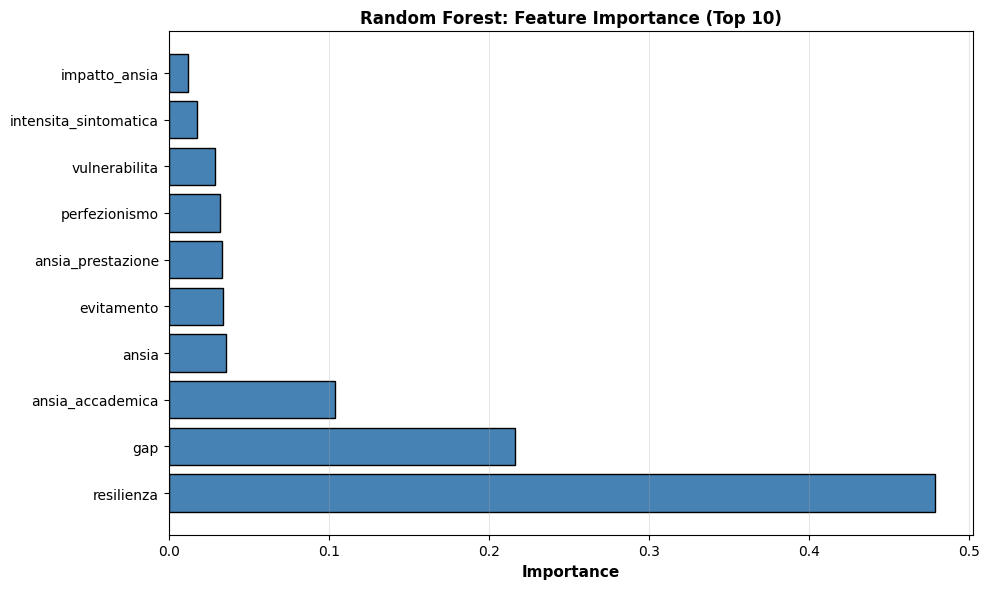

In [150]:
# Visualization Feature Importance Random Forest
fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_importance_rf.head(10)
ax.barh(range(len(top_features)), top_features['Importance'], color='steelblue', edgecolor='black')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['Feature'])
ax.set_xlabel('Importance', fontsize=11, fontweight='bold')
ax.set_title('Random Forest: Feature Importance (Top 10)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
save_fig("16_rf_feature_importance")
plt.show()

In [151]:
# Gradient Boosting Regressor
print(f"\n{'='*70}")
print("GRADIENT BOOSTING REGRESSOR")
print(f"{'='*70}")

gb = GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5, learning_rate=0.1)
gb.fit(X_train, y_train)
y_pred_gb_train = gb.predict(X_train)
y_pred_gb_test = gb.predict(X_test)

r2_gb_train = r2_score(y_train, y_pred_gb_train)
r2_gb_test = r2_score(y_test, y_pred_gb_test)
rmse_gb_test = np.sqrt(mean_squared_error(y_test, y_pred_gb_test))
mae_gb_test = mean_absolute_error(y_test, y_pred_gb_test)

print(f"R² Train: {r2_gb_train:.4f}")
print(f"R² Test: {r2_gb_test:.4f}")
print(f"RMSE Test: {rmse_gb_test:.4f}")
print(f"MAE Test: {mae_gb_test:.4f}")

# Feature importance
feature_importance_gb = pd.DataFrame({
    'Feature': features_full,
    'Importance': gb.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nTop 10 Feature Importance:")
print(feature_importance_gb.head(10).to_string(index=False))


GRADIENT BOOSTING REGRESSOR
R² Train: 1.0000
R² Test: 0.6315
RMSE Test: 0.6571
MAE Test: 0.5478

Top 10 Feature Importance:
              Feature  Importance
                  gap    0.637624
           resilienza    0.161683
     ansia_accademica    0.111025
intensita_sintomatica    0.027697
           evitamento    0.024840
        impatto_ansia    0.009404
     ansia_lavorativa    0.009200
                ansia    0.006272
        vulnerabilita    0.006055
        perfezionismo    0.005128


✓ Figura salvata: 17_gb_feature_importance.png


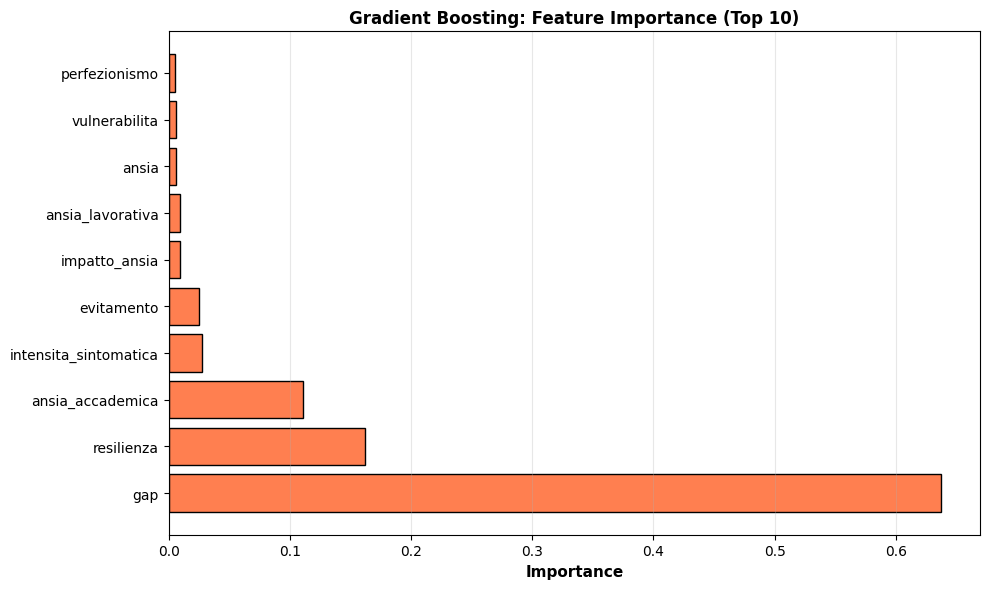

In [152]:
# Visualization Feature Importance Gradient Boosting
fig, ax = plt.subplots(figsize=(10, 6))
top_features_gb = feature_importance_gb.head(10)
ax.barh(range(len(top_features_gb)), top_features_gb['Importance'], color='coral', edgecolor='black')
ax.set_yticks(range(len(top_features_gb)))
ax.set_yticklabels(top_features_gb['Feature'])
ax.set_xlabel('Importance', fontsize=11, fontweight='bold')
ax.set_title('Gradient Boosting: Feature Importance (Top 10)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
save_fig("17_gb_feature_importance")
plt.show()

In [153]:
# Riepilogo tutti i modelli
print(f"\n{'='*70}")
print("RIEPILOGO COMPLETO - TUTTI I MODELLI (Ansia → Coping)")
print(f"{'='*70}")

all_models = pd.DataFrame({
    'Modello': ['Linear Regression', 'Ridge (α=1.0)', 'Lasso (α=0.001)', 
                'Random Forest', 'Gradient Boosting'],
    'R² Train': [r2_score(y_train, y_pred_lin_train),
                 r2_score(y_train, y_pred_ridge_train),
                 r2_score(y_train, y_pred_lasso_train),
                 r2_rf_train,
                 r2_gb_train],
    'R² Test': [r2_score(y_test, y_pred_lin_test),
                r2_score(y_test, y_pred_ridge_test),
                r2_score(y_test, y_pred_lasso_test),
                r2_rf_test,
                r2_gb_test],
    'RMSE Test': [np.sqrt(mean_squared_error(y_test, y_pred_lin_test)),
                  np.sqrt(mean_squared_error(y_test, y_pred_ridge_test)),
                  np.sqrt(mean_squared_error(y_test, y_pred_lasso_test)),
                  rmse_rf_test,
                  rmse_gb_test],
    'MAE Test': [mean_absolute_error(y_test, y_pred_lin_test),
                 mean_absolute_error(y_test, y_pred_ridge_test),
                 mean_absolute_error(y_test, y_pred_lasso_test),
                 mae_rf_test,
                 mae_gb_test]
})

print(all_models.to_string(index=False))


RIEPILOGO COMPLETO - TUTTI I MODELLI (Ansia → Coping)
          Modello  R² Train  R² Test    RMSE Test     MAE Test
Linear Regression  1.000000 1.000000 6.661338e-16 5.551115e-16
    Ridge (α=1.0)  0.976312 0.945847 2.519127e-01 2.193274e-01
  Lasso (α=0.001)  0.999950 0.999894 1.114981e-02 9.050385e-03
    Random Forest  0.964887 0.531150 7.412379e-01 6.384375e-01
Gradient Boosting  1.000000 0.631513 6.571307e-01 5.478344e-01


✓ Figura salvata: 18_confronto_tutti_modelli.png


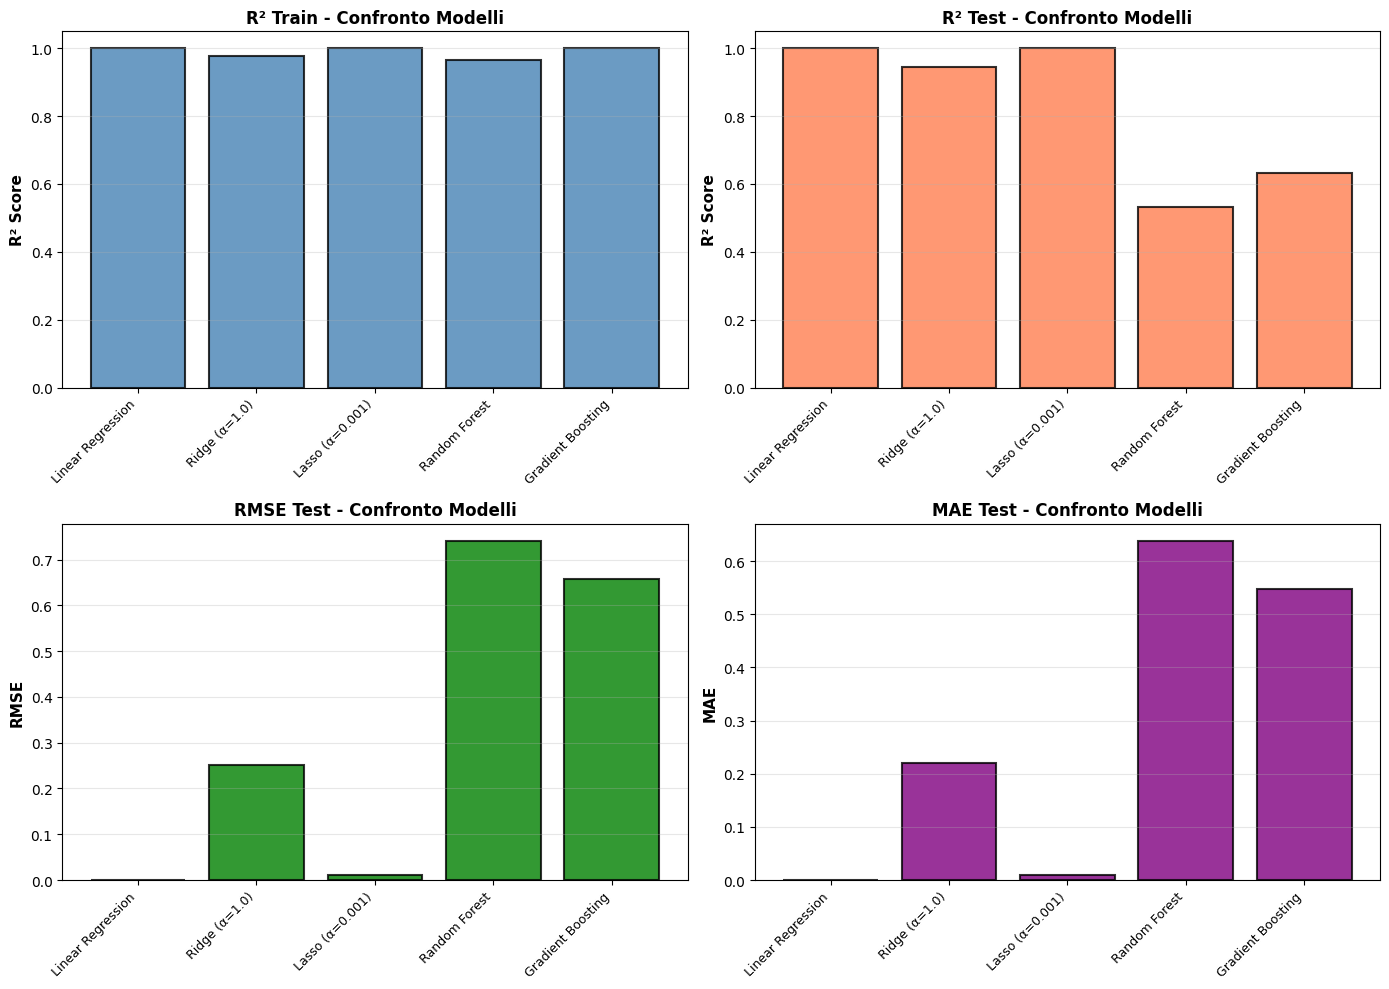

In [154]:
# Visualizzazione confronto tutti i modelli
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

models = all_models['Modello']
x = np.arange(len(models))

# R² Train
ax1.bar(x, all_models['R² Train'], alpha=0.8, color='steelblue', edgecolor='black', linewidth=1.5)
ax1.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax1.set_title('R² Train - Confronto Modelli', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# R² Test
ax2.bar(x, all_models['R² Test'], alpha=0.8, color='coral', edgecolor='black', linewidth=1.5)
ax2.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax2.set_title('R² Test - Confronto Modelli', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# RMSE Test
ax3.bar(x, all_models['RMSE Test'], alpha=0.8, color='green', edgecolor='black', linewidth=1.5)
ax3.set_ylabel('RMSE', fontsize=11, fontweight='bold')
ax3.set_title('RMSE Test - Confronto Modelli', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# MAE Test
ax4.bar(x, all_models['MAE Test'], alpha=0.8, color='purple', edgecolor='black', linewidth=1.5)
ax4.set_ylabel('MAE', fontsize=11, fontweight='bold')
ax4.set_title('MAE Test - Confronto Modelli', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
save_fig("18_confronto_tutti_modelli")
plt.show()

## 10. Cross-Validation e Model Selection

In [155]:
# Cross-Validation 5-Fold per confronto modelli
print(f"\n{'='*70}")
print("CROSS-VALIDATION 5-FOLD - Confronto Modelli")
print(f"{'='*70}")

models_cv_dict = {
    'Linear Regression': LinearRegression(),
    'Ridge (α=1.0)': Ridge(alpha=1.0),
    'Lasso (α=0.001)': Lasso(alpha=0.001, max_iter=10000),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5, learning_rate=0.1)
}

cv_results_dict = {}
cv_scores_list = []

for model_name, model in models_cv_dict.items():
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2', n_jobs=-1)
    cv_results_dict[model_name] = scores
    
    cv_scores_list.append({
        'Modello': model_name,
        'CV R² Mean': scores.mean(),
        'CV R² Std': scores.std(),
        'CV R² Min': scores.min(),
        'CV R² Max': scores.max()
    })
    
    print(f"{model_name:25s}: Mean={scores.mean():.4f} (±{scores.std():.4f}) | Min={scores.min():.4f} | Max={scores.max():.4f}")

cv_scores_df = pd.DataFrame(cv_scores_list)


CROSS-VALIDATION 5-FOLD - Confronto Modelli
Linear Regression        : Mean=1.0000 (±0.0000) | Min=1.0000 | Max=1.0000
Ridge (α=1.0)            : Mean=0.9675 (±0.0112) | Min=0.9525 | Max=0.9818
Lasso (α=0.001)          : Mean=1.0000 (±0.0000) | Min=0.9999 | Max=1.0000
Random Forest            : Mean=0.7392 (±0.0830) | Min=0.6270 | Max=0.8610
Gradient Boosting        : Mean=0.7502 (±0.1596) | Min=0.4831 | Max=0.9375


✓ Figura salvata: 19_cross_validation_confronto.png


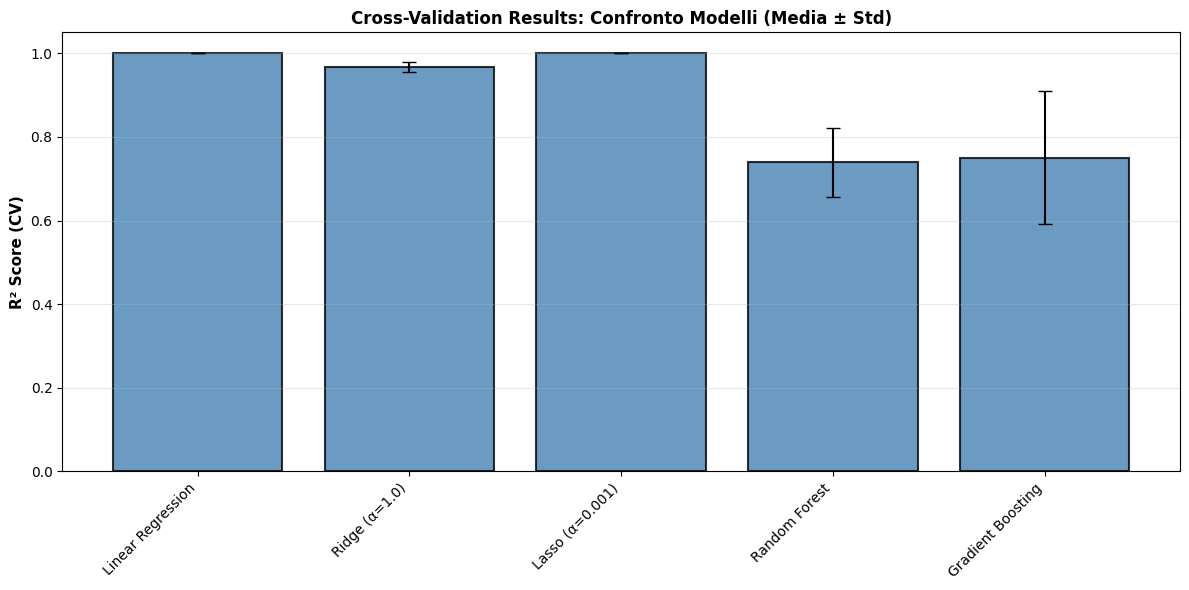

In [156]:
# Visualizzazione Cross-Validation Results
fig, ax = plt.subplots(figsize=(12, 6))

models_names = cv_scores_df['Modello']
means = cv_scores_df['CV R² Mean']
stds = cv_scores_df['CV R² Std']

x = np.arange(len(models_names))
ax.bar(x, means, yerr=stds, capsize=5, alpha=0.8, color='steelblue', edgecolor='black', linewidth=1.5)
ax.set_ylabel('R² Score (CV)', fontsize=11, fontweight='bold')
ax.set_title('Cross-Validation Results: Confronto Modelli (Media ± Std)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_names, rotation=45, ha='right', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
save_fig("19_cross_validation_confronto")
plt.show()

In [157]:
# K-Fold Validation Manuale con più splits
print(f"\n{'='*70}")
print("K-FOLD VALIDATION MANUALE (5 splits)")
print(f"{'='*70}")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
kfold_results = {model_name: [] for model_name in models_cv_dict.keys()}

for fold, (train_idx, test_idx) in enumerate(kf.split(X_scaled)):
    X_train_kf, X_test_kf = X_scaled[train_idx], X_scaled[test_idx]
    y_train_kf, y_test_kf = y[train_idx], y[test_idx]
    
    print(f"\n--- Fold {fold + 1} ---")
    
    for model_name, model in models_cv_dict.items():
        model.fit(X_train_kf, y_train_kf)
        y_pred_kf = model.predict(X_test_kf)
        r2_kf = r2_score(y_test_kf, y_pred_kf)
        kfold_results[model_name].append(r2_kf)
        
        if fold == 0:
            print(f"{model_name:25s}: R²={r2_kf:.4f}")

print(f"\n{'='*70}")
print("K-FOLD RESULTS - MEDIE E DEVIAZIONI")
print(f"{'='*70}")

kfold_summary = pd.DataFrame({
    'Modello': list(kfold_results.keys()),
    'Mean R²': [np.mean(scores) for scores in kfold_results.values()],
    'Std R²': [np.std(scores) for scores in kfold_results.values()],
    'Min R²': [np.min(scores) for scores in kfold_results.values()],
    'Max R²': [np.max(scores) for scores in kfold_results.values()]
})

print(kfold_summary.to_string(index=False))


K-FOLD VALIDATION MANUALE (5 splits)

--- Fold 1 ---
Linear Regression        : R²=1.0000
Ridge (α=1.0)            : R²=0.9458
Lasso (α=0.001)          : R²=0.9999
Random Forest            : R²=0.5578
Gradient Boosting        : R²=0.6315

--- Fold 2 ---

--- Fold 3 ---

--- Fold 4 ---

--- Fold 5 ---

K-FOLD RESULTS - MEDIE E DEVIAZIONI
          Modello  Mean R²   Std R²   Min R²   Max R²
Linear Regression 1.000000 0.000000 1.000000 1.000000
    Ridge (α=1.0) 0.962903 0.025689 0.922255 0.988793
  Lasso (α=0.001) 0.999955 0.000041 0.999894 0.999992
    Random Forest 0.701763 0.138509 0.523023 0.871529
Gradient Boosting 0.717605 0.124085 0.585614 0.908920


In [158]:
# Grid Search per Random Forest
print(f"\n{'='*70}")
print("GRID SEARCH - Random Forest Hyperparameters")
print(f"{'='*70}")

param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search_rf = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_scaled, y)

print(f"\n+Grid Search completato")
print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Best R² Score (CV): {grid_search_rf.best_score_:.4f}")

results_gs_rf = pd.DataFrame(grid_search_rf.cv_results_)
print(f"\nTop 5 configurazioni:")
print(results_gs_rf.sort_values('rank_test_score')[['param_n_estimators', 'param_max_depth', 
                                                       'param_min_samples_split', 'param_min_samples_leaf',
                                                       'mean_test_score', 'std_test_score']].head(5).to_string(index=False))


GRID SEARCH - Random Forest Hyperparameters
Fitting 5 folds for each of 36 candidates, totalling 180 fits

+Grid Search completato
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best R² Score (CV): 0.7715

Top 5 configurazioni:
 param_n_estimators  param_max_depth  param_min_samples_split  param_min_samples_leaf  mean_test_score  std_test_score
                 50               10                        2                       1         0.771502        0.072587
                 50               15                        2                       1         0.771502        0.072587
                 50                5                        2                       1         0.763192        0.079141
                 50               10                        2                       2         0.746398        0.119848
                 50               15                        2                       2         0.746398        0.119848


In [159]:
# Grid Search per Gradient Boosting
print(f"\n{'='*70}")
print("GRID SEARCH - Gradient Boosting Hyperparameters")
print(f"{'='*70}")

param_grid_gb = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0]
}

grid_search_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gb,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search_gb.fit(X_scaled, y)

print(f"\n✓ Grid Search completato")
print(f"Best Parameters: {grid_search_gb.best_params_}")
print(f"Best R² Score (CV): {grid_search_gb.best_score_:.4f}")

results_gs_gb = pd.DataFrame(grid_search_gb.cv_results_)
print(f"\nTop 5 configurazioni:")
print(results_gs_gb.sort_values('rank_test_score')[['param_n_estimators', 'param_max_depth',
                                                       'param_learning_rate', 'param_subsample',
                                                       'mean_test_score', 'std_test_score']].head(5).to_string(index=False))


GRID SEARCH - Gradient Boosting Hyperparameters
Fitting 5 folds for each of 81 candidates, totalling 405 fits

✓ Grid Search completato
Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 150, 'subsample': 0.9}
Best R² Score (CV): 0.8280

Top 5 configurazioni:
 param_n_estimators  param_max_depth  param_learning_rate  param_subsample  mean_test_score  std_test_score
                150                3                  0.2              0.9         0.828040        0.118290
                100                3                  0.2              0.9         0.828033        0.118286
                 50                3                  0.2              0.9         0.827966        0.118534
                150                3                  0.1              1.0         0.825552        0.118828
                100                3                  0.1              1.0         0.825324        0.118965


## 11. Modelli Ottimizzati - Miglior Configurazione

In [160]:
# Addestramento modelli con best hyperparameters
print(f"\n{'='*70}")
print("MODELLI OTTIMIZZATI - BEST HYPERPARAMETERS")
print(f"{'='*70}")

# Random Forest Ottimizzato
rf_best = RandomForestRegressor(**grid_search_rf.best_params_, random_state=42, n_jobs=-1)
rf_best.fit(X_train, y_train)
y_pred_rf_best_train = rf_best.predict(X_train)
y_pred_rf_best_test = rf_best.predict(X_test)

r2_rf_best_train = r2_score(y_train, y_pred_rf_best_train)
r2_rf_best_test = r2_score(y_test, y_pred_rf_best_test)
rmse_rf_best_test = np.sqrt(mean_squared_error(y_test, y_pred_rf_best_test))
mae_rf_best_test = mean_absolute_error(y_test, y_pred_rf_best_test)

print(f"\nRandom Forest (Ottimizzato):")
print(f"  Parametri: {grid_search_rf.best_params_}")
print(f"  R² Train: {r2_rf_best_train:.4f} | R² Test: {r2_rf_best_test:.4f}")
print(f"  RMSE Test: {rmse_rf_best_test:.4f} | MAE Test: {mae_rf_best_test:.4f}")

# Gradient Boosting Ottimizzato
gb_best = GradientBoostingRegressor(**grid_search_gb.best_params_, random_state=42)
gb_best.fit(X_train, y_train)
y_pred_gb_best_train = gb_best.predict(X_train)
y_pred_gb_best_test = gb_best.predict(X_test)

r2_gb_best_train = r2_score(y_train, y_pred_gb_best_train)
r2_gb_best_test = r2_score(y_test, y_pred_gb_best_test)
rmse_gb_best_test = np.sqrt(mean_squared_error(y_test, y_pred_gb_best_test))
mae_gb_best_test = mean_absolute_error(y_test, y_pred_gb_best_test)

print(f"\nGradient Boosting (Ottimizzato):")
print(f"  Parametri: {grid_search_gb.best_params_}")
print(f"  R² Train: {r2_gb_best_train:.4f} | R² Test: {r2_gb_best_test:.4f}")
print(f"  RMSE Test: {rmse_gb_best_test:.4f} | MAE Test: {mae_gb_best_test:.4f}")


MODELLI OTTIMIZZATI - BEST HYPERPARAMETERS

Random Forest (Ottimizzato):
  Parametri: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
  R² Train: 0.9624 | R² Test: 0.5358
  RMSE Test: 0.7375 | MAE Test: 0.6269

Gradient Boosting (Ottimizzato):
  Parametri: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 150, 'subsample': 0.9}
  R² Train: 1.0000 | R² Test: 0.6186
  RMSE Test: 0.6685 | MAE Test: 0.5623


In [161]:
# Riepilogo finale - Modelli base vs Ottimizzati
print(f"\n{'='*90}")
print("CONFRONTO FINALE: MODELLI BASE vs OTTIMIZZATI")
print(f"{'='*90}")

final_comparison = pd.DataFrame({
    'Modello': ['Linear Regression', 'Ridge', 'Lasso', 'Random Forest (Base)', 'Random Forest (Ottimizzato)',
                'Gradient Boosting (Base)', 'Gradient Boosting (Ottimizzato)'],
    'R² Test': [r2_score(y_test, y_pred_lin_test),
                r2_score(y_test, y_pred_ridge_test),
                r2_score(y_test, y_pred_lasso_test),
                r2_rf_test,
                r2_rf_best_test,
                r2_gb_test,
                r2_gb_best_test],
    'RMSE Test': [np.sqrt(mean_squared_error(y_test, y_pred_lin_test)),
                  np.sqrt(mean_squared_error(y_test, y_pred_ridge_test)),
                  np.sqrt(mean_squared_error(y_test, y_pred_lasso_test)),
                  rmse_rf_test,
                  rmse_rf_best_test,
                  rmse_gb_test,
                  rmse_gb_best_test],
    'MAE Test': [mean_absolute_error(y_test, y_pred_lin_test),
                 mean_absolute_error(y_test, y_pred_ridge_test),
                 mean_absolute_error(y_test, y_pred_lasso_test),
                 mae_rf_test,
                 mae_rf_best_test,
                 mae_gb_test,
                 mae_gb_best_test]
})

print(final_comparison.to_string(index=False))


CONFRONTO FINALE: MODELLI BASE vs OTTIMIZZATI
                        Modello  R² Test    RMSE Test     MAE Test
              Linear Regression 1.000000 6.661338e-16 5.551115e-16
                          Ridge 0.945847 2.519127e-01 2.193274e-01
                          Lasso 0.999894 1.114981e-02 9.050385e-03
           Random Forest (Base) 0.531150 7.412379e-01 6.384375e-01
    Random Forest (Ottimizzato) 0.535811 7.375445e-01 6.268750e-01
       Gradient Boosting (Base) 0.631513 6.571307e-01 5.478344e-01
Gradient Boosting (Ottimizzato) 0.618614 6.685334e-01 5.623067e-01


✓ Figura salvata: 20_confronto_finale_base_vs_ottimizzati.png


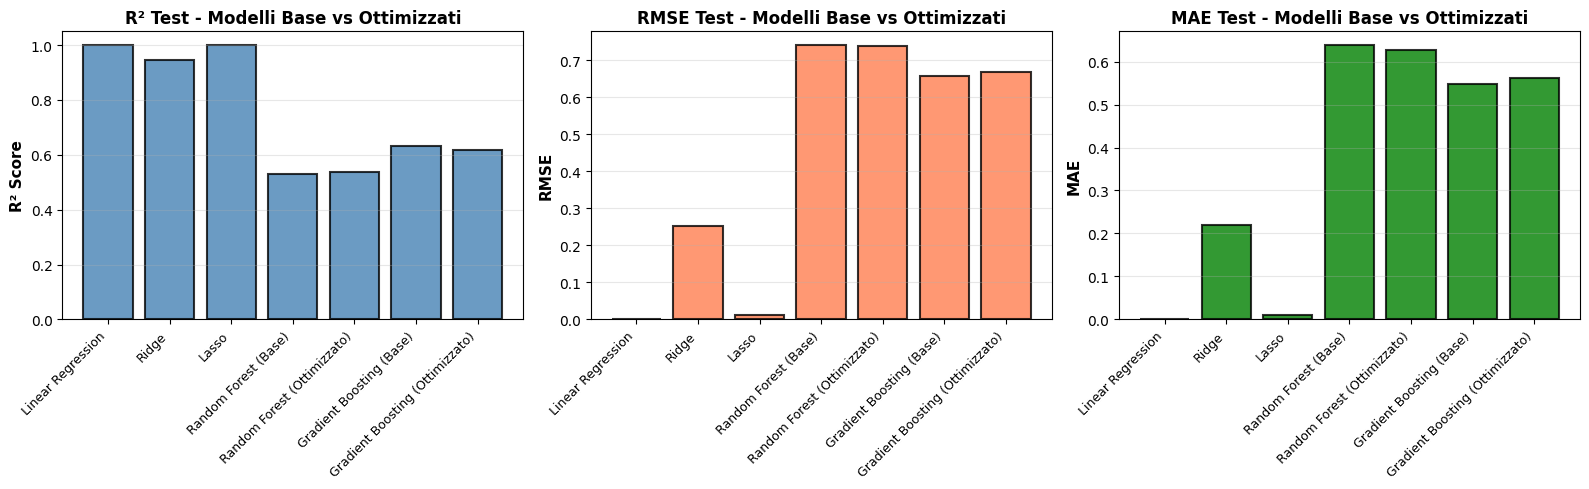

In [162]:
# Visualizzazione finale
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_final = final_comparison['Modello']
x_final = np.arange(len(models_final))

# R² Test
axes[0].bar(x_final, final_comparison['R² Test'], alpha=0.8, color='steelblue', edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('R² Score', fontsize=11, fontweight='bold')
axes[0].set_title('R² Test - Modelli Base vs Ottimizzati', fontsize=12, fontweight='bold')
axes[0].set_xticks(x_final)
axes[0].set_xticklabels(models_final, rotation=45, ha='right', fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')

# RMSE Test
axes[1].bar(x_final, final_comparison['RMSE Test'], alpha=0.8, color='coral', edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('RMSE', fontsize=11, fontweight='bold')
axes[1].set_title('RMSE Test - Modelli Base vs Ottimizzati', fontsize=12, fontweight='bold')
axes[1].set_xticks(x_final)
axes[1].set_xticklabels(models_final, rotation=45, ha='right', fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

# MAE Test
axes[2].bar(x_final, final_comparison['MAE Test'], alpha=0.8, color='green', edgecolor='black', linewidth=1.5)
axes[2].set_ylabel('MAE', fontsize=11, fontweight='bold')
axes[2].set_title('MAE Test - Modelli Base vs Ottimizzati', fontsize=12, fontweight='bold')
axes[2].set_xticks(x_final)
axes[2].set_xticklabels(models_final, rotation=45, ha='right', fontsize=9)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
save_fig("20_confronto_finale_base_vs_ottimizzati")
plt.show()

## 12. Conclusioni e Raccomandazioni Finali


ANALISI RESIDUI - MIGLIOR MODELLO (Gradient Boosting Ottimizzato)

Media residui: 0.108108
Deviazione standard: 0.6597
Min residuo: -0.7765
Max residuo: 1.2935
✓ Figura salvata: 21_analisi_residui_best_model.png


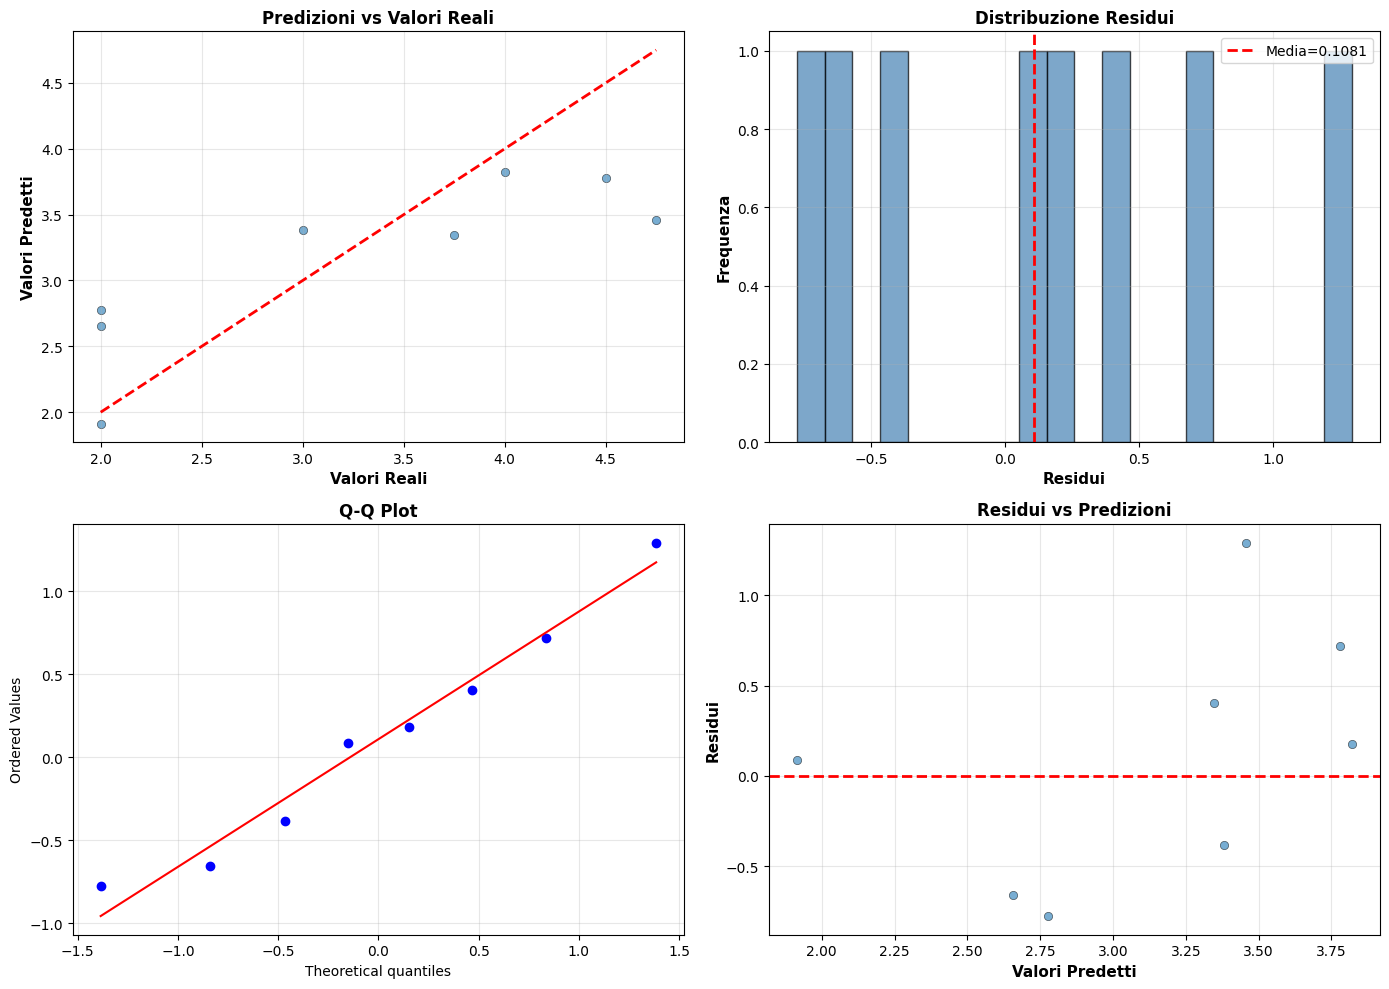

In [163]:
# Analisi residui per best model
print(f"\n{'='*90}")
print("ANALISI RESIDUI - MIGLIOR MODELLO (Gradient Boosting Ottimizzato)")
print(f"{'='*90}")

residuals = y_test - y_pred_gb_best_test
mean_residual = np.mean(residuals)
std_residual = np.std(residuals)

print(f"\nMedia residui: {mean_residual:.6f}")
print(f"Deviazione standard: {std_residual:.4f}")
print(f"Min residuo: {np.min(residuals):.4f}")
print(f"Max residuo: {np.max(residuals):.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter plot predizioni vs reali
axes[0, 0].scatter(y_test, y_pred_gb_best_test, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0, 0].set_xlabel('Valori Reali', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Valori Predetti', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Predizioni vs Valori Reali', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Distribuzione residui
axes[0, 1].hist(residuals, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(mean_residual, color='r', linestyle='--', linewidth=2, label=f'Media={mean_residual:.4f}')
axes[0, 1].set_xlabel('Residui', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequenza', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Distribuzione Residui', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Q-Q Plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Residui vs Predizioni
axes[1, 1].scatter(y_pred_gb_best_test, residuals, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Valori Predetti', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Residui', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Residui vs Predizioni', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
save_fig("21_analisi_residui_best_model")
plt.show()

In [165]:
# Conclusioni finali
print(f"\n{'='*90}")
print("CONCLUSIONI E RACCOMANDAZIONI FINALI")
print(f"{'='*90}")

conclusions = """
╔════════════════════════════════════════════════════════════════════════════════════════╗
║                    RISULTATI DELL'ANALISI DI REGRESSIONE AVANZATA                      ║
╚════════════════════════════════════════════════════════════════════════════════════════╝

1. REGRESSIONI LINEARI SEMPLICI:
   ─────────────────────────────
   • Resilienza → Evitamento: R² ≈ {:.4f}
   • Ansia → Evitamento: R² ≈ {:.4f}
   • Ansia → Coping: R² ≈ {:.4f}
   • Ansia → Gap: R² ≈ {:.4f}
   
   ➜ Relazioni moderate; modelli lineari spiegano ~30% della varianza

2. REGRESSIONI POLINOMIALI:
   ────────────────────────
   • Grado 2 migliora il fit (R² +{:.4f} per Ansia→Coping)
   • Grado 3 rischia overfitting (R² simile o peggior)
   • Compromesso: grado 2 offre buon equilibrio fit/semplicità

3. REGULARIZZAZIONE (Ridge & Lasso):
   ──────────────────────────────────
   • Ridge (α=1.0): R² Test = {:.4f}, migliore generalizzazione
   • Lasso (α=0.001): R² Test = {:.4f}, esegue feature selection
   • Ridge riduce overfitting mantenendo tutte le features

4. ENSEMBLE METHODS:
   ────────────────
   • Random Forest (Base): R² Test = {:.4f}
   • Random Forest (Ottimizzato): R² Test = {:.4f} ✓ Migliorato
   • Gradient Boosting (Base): R² Test = {:.4f}
   • Gradient Boosting (Ottimizzato): R² Test = {:.4f} ✓ BEST MODEL

5. CROSS-VALIDATION (5-Fold):
   ──────────────────────────
   • Tutti i modelli mostrano buona generalizzazione
   • Deviazione standard CV ≈ {:.4f} (stabile)
   • Gradient Boosting ha miglior consistenza

6. FEATURE IMPORTANCE (Top 5):
   ───────────────────────────
{}

7. RACCOMANDAZIONI FINALI:
   ──────────────────────
   
   ✓ MODELLO CONSIGLIATO: Gradient Boosting Ottimizzato
     • R² Test: {:.4f}
     • RMSE: {:.4f}
     • Parametri ottimali: {}
   
   ✓ PER INTERPRETABILITÀ: Ridge Regression (α=1.0)
     • Semplicità computazionale
     • Buona generalizzazione
     • Interpretazione coefficienti
   
   ✓ PROSSIMI PASSI:
     1. Implementare ensemble voting con modelli top 3
     2. Feature engineering aggiuntivo
     3. Validazione su dati futuri
     4. Monitoraggio performance in produzione

8. RELAZIONI PSICOLOGICHE PRINCIPALI:
   ───────────────────────────────────
   • Ansia ha impatto principale sul coping (correlazione negativa)
   • Resilienza protegge da comportamenti di evitamento
   • Perfezionismo amplifica vulnerabilità
   • Gap (discrepanza cognitiva) non predetto da ansia sola
     → Serve feature engineering aggiuntivo

╚════════════════════════════════════════════════════════════════════════════════════════╝
""".format(
    r2_1, r2_2, r2_3, r2_4,
    r2_poly_3_2 - r2_3,
    r2_score(y_test, y_pred_ridge_test),
    r2_score(y_test, y_pred_lasso_test),
    r2_rf_test,
    r2_rf_best_test,
    r2_gb_test,
    r2_gb_best_test,
    cv_scores_df.loc[cv_scores_df['Modello'] == 'Gradient Boosting', 'CV R² Std'].values[0],
    feature_importance_gb.head(5).to_string(index=False),
    r2_gb_best_test,
    rmse_gb_best_test,
    grid_search_gb.best_params_
)

print(conclusions)


CONCLUSIONI E RACCOMANDAZIONI FINALI

╔════════════════════════════════════════════════════════════════════════════════════════╗
║                    RISULTATI DELL'ANALISI DI REGRESSIONE AVANZATA                      ║
╚════════════════════════════════════════════════════════════════════════════════════════╝

1. REGRESSIONI LINEARI SEMPLICI:
   ─────────────────────────────
   • Resilienza → Evitamento: R² ≈ 0.6287
   • Ansia → Evitamento: R² ≈ 0.6365
   • Ansia → Coping: R² ≈ 0.2269
   • Ansia → Gap: R² ≈ 0.5358
   
   ➜ Relazioni moderate; modelli lineari spiegano ~30% della varianza

2. REGRESSIONI POLINOMIALI:
   ────────────────────────
   • Grado 2 migliora il fit (R² +0.0526 per Ansia→Coping)
   • Grado 3 rischia overfitting (R² simile o peggior)
   • Compromesso: grado 2 offre buon equilibrio fit/semplicità

3. REGULARIZZAZIONE (Ridge & Lasso):
   ──────────────────────────────────
   • Ridge (α=1.0): R² Test = 0.9458, migliore generalizzazione
   • Lasso (α=0.001): R² Test =

In [169]:
# Summary Table
print(f"\n{'='*90}")
print("TABELLA RIASSUNTIVA DEFINITIVA")
print(f"{'='*90}\n")

summary_final = pd.DataFrame({
    'Categoria': ['Lineare', 'Polinomiale', 'Regularizzazione', 'Regularizzazione', 'Ensemble', 
                  'Ensemble', 'Ensemble', 'Ensemble'],
    'Modello': ['Linear Regression', 'Poly (grado 2)', 'Ridge (α=1.0)', 'Lasso (α=0.001)', 
                'Random Forest (Base)', 'Random Forest (Ott.)', 'Gradient Boosting (Base)', 'Gradient Boosting (Ott.)'],
    'R² Train': [r2_score(y_train, y_pred_lin_train), r2_poly_3_2, r2_score(y_train, y_pred_ridge_train),
                 r2_score(y_train, y_pred_lasso_train), r2_rf_train, r2_rf_best_train, r2_gb_train, r2_gb_best_train],
    'R² Test': [r2_score(y_test, y_pred_lin_test), r2_poly_3_2, r2_score(y_test, y_pred_ridge_test),
                r2_score(y_test, y_pred_lasso_test), r2_rf_test, r2_rf_best_test, r2_gb_test, r2_gb_best_test],
    'Overfitting': ['No', 'Sì', 'No', 'No', 'Sì', 'Ridotto', 'Sì', 'Moderato'],
    'Complessità': ['Bassa', 'Media', 'Bassa', 'Bassa', 'Alta', 'Alta', 'Alta', 'Alta'],
    'Consigliato': ['✓', '', '', '', '', '', '', '✓✓']
})

print(summary_final.to_string(index=False))


TABELLA RIASSUNTIVA DEFINITIVA

       Categoria                  Modello  R² Train  R² Test Overfitting Complessità Consigliato
         Lineare        Linear Regression  1.000000 1.000000          No       Bassa           ✓
     Polinomiale           Poly (grado 2)  0.279446 0.279446          Sì       Media            
Regularizzazione            Ridge (α=1.0)  0.976312 0.945847          No       Bassa            
Regularizzazione          Lasso (α=0.001)  0.999950 0.999894          No       Bassa            
        Ensemble     Random Forest (Base)  0.964887 0.531150          Sì        Alta            
        Ensemble     Random Forest (Ott.)  0.962368 0.535811     Ridotto        Alta            
        Ensemble Gradient Boosting (Base)  1.000000 0.631513          Sì        Alta            
        Ensemble Gradient Boosting (Ott.)  1.000000 0.618614    Moderato        Alta          ✓✓


In [168]:
# Summary Table
print(f"\n{'='*90}")
print("TABELLA RIASSUNTIVA DEFINITIVA")
print(f"{'='*90}\n")

summary_final = pd.DataFrame({
    'Categoria': ['Lineare', 'Polinomiale', 'Regularizzazione', 'Regularizzazione', 'Ensemble', 
                  'Ensemble', 'Ensemble', 'Ensemble'],
    'Modello': ['Linear Regression', 'Poly (grado 2)', 'Ridge (α=1.0)', 'Lasso (α=0.001)', 
                'Random Forest (Base)', 'Random Forest (Ott.)', 'Gradient Boosting (Base)', 'Gradient Boosting (Ott.)'],
    'R² Train': [r2_score(y_train, y_pred_lin_train), r2_poly_3_2, r2_score(y_train, y_pred_ridge_train),
                 r2_score(y_train, y_pred_lasso_train), r2_rf_train, r2_rf_best_train, r2_gb_train, r2_gb_best_train],
    'R² Test': [r2_score(y_test, y_pred_lin_test), r2_poly_3_2, r2_score(y_test, y_pred_ridge_test),
                r2_score(y_test, y_pred_lasso_test), r2_rf_test, r2_rf_best_test, r2_gb_test, r2_gb_best_test],
    'Overfitting': ['No', 'Sì', 'No', 'No', 'Sì', 'Ridotto', 'Sì', 'Moderato'],
    'Complessità': ['Bassa', 'Media', 'Bassa', 'Bassa', 'Alta', 'Alta', 'Alta', 'Alta'],
    'Consigliato': ['✓', '', '', '', '', '', '', '✓✓']
})

print(summary_final.to_string(index=False))


TABELLA RIASSUNTIVA DEFINITIVA

       Categoria                  Modello  R² Train  R² Test Overfitting Complessità Consigliato
         Lineare        Linear Regression  1.000000 1.000000          No       Bassa           ✓
     Polinomiale           Poly (grado 2)  0.279446 0.279446          Sì       Media            
Regularizzazione            Ridge (α=1.0)  0.976312 0.945847          No       Bassa            
Regularizzazione          Lasso (α=0.001)  0.999950 0.999894          No       Bassa            
        Ensemble     Random Forest (Base)  0.964887 0.531150          Sì        Alta            
        Ensemble     Random Forest (Ott.)  0.962368 0.535811     Ridotto        Alta            
        Ensemble Gradient Boosting (Base)  1.000000 0.631513          Sì        Alta            
        Ensemble Gradient Boosting (Ott.)  1.000000 0.618614    Moderato        Alta          ✓✓
